# Curating Initial Populations by Iteration Budget (opro-only)

Variation of `Multi_Tasks_Curating_Initial_Populations_for_Discovery_Roll_Outs.ipynb`'s
score-x-diversity grid curation, but sliced by **iteration budget** instead of pooling a
run's entire history.

An "iteration budget" `N` restricts each rollout run's contribution to only the first `N`
entries of its `long_running_solution_bank.json` (keys `"1".."N"`, which are written in
iteration order -- see `active_population` in each entry, a monotonically growing list that
confirms key order == discovery order). This lets us study how initial-population score/
diversity structure differs depending on how much population history downstream algorithms
are allowed to pull from, the same way the original notebook's tweet section swept `n_settings`.

Only **opro**-optimizer runs (`opro_*` directories) under `general_rollout/` are pooled here --
`gepa_*` runs are excluded. Six tasks are covered, each with its own budget list:

| Task | Iteration budgets |
|---|---|
| kernelbench | 3, 5, 10 |
| cloudcast | 3, 5, 10, 15 |
| cantbelate | 3, 10, 20, 50, 70 |
| harmbench | 5, 10, 50 |
| prompt / gsm8k | 10, 20, 50 |
| prompt / drop | 5, 10, 20, 50 |

Populations are written to a **new** output directory
(`curated_initial_populations_by_iter_budget/<task>/budget_<N>/Row_i_Col_j.json`) so nothing
in `curated_initial_populations_v2/` (produced by the original notebook) is touched or
overwritten.

In [1]:
from __future__ import annotations

import gc
import glob
import json
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

GENERAL_ROLLOUT_DIR = '/scratch/mansisak/llm_optimizer/general_rollout'

# Separate output tree from the original notebook's curated_initial_populations_v2/ --
# these populations are sliced by iteration budget and restricted to opro runs only, so
# they shouldn't land in (or overwrite anything in) that directory.
POPULATION_DIR = '/scratch/mansisak/llm_optimizer/curated_initial_populations_by_iter_budget_scratch'

# Reuse the same on-disk embedding cache as the other curation notebooks -- cache entries
# are keyed per solution string + model name (see embed_with_cache below), so sharing this
# directory is safe: identical solution text embeds identically regardless of which
# notebook/run produced it, and cache_key below is namespaced per task so nothing collides
# with the full-history cache entries the original notebook already wrote.
EMBEDDING_CACHE_DIR = '/scratch/mansisak/llm_optimizer/embedding_cache'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Embedding device: {DEVICE}')

Embedding device: cpu


In [2]:
def embed_with_cache(
    texts,
    model_name,
    cache_key,
    device=DEVICE,
    trust_remote_code=False,
    batch_size=32,
    max_seq_length=None,
    cache_dir=EMBEDDING_CACHE_DIR,
):
    """SentenceTransformer.encode(), but persisted to disk keyed by (cache_key, model_name)
    so re-running a notebook cell -- or a later notebook entirely -- doesn't re-pay for
    embeddings it already computed. Cached per solution string (not per DataFrame row), so
    pooling a larger iteration budget for the same task only pays for the newly-seen
    strings; everything a smaller budget already embedded is reused as-is.

    Identical to the helper in Multi_Tasks_Curating_Initial_Populations_for_Discovery_Roll_Outs.ipynb
    -- duplicated here rather than imported since notebooks don't share Python modules, but
    kept byte-for-byte equivalent so cache files stay interchangeable.
    """
    os.makedirs(cache_dir, exist_ok=True)
    safe_model_name = model_name.replace('/', '__')
    cache_path = os.path.join(cache_dir, f'{cache_key}__{safe_model_name}.pkl')

    cache = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)
        print(
            f'embed_with_cache[{cache_key}]: loaded {len(cache)} cached embeddings from {cache_path}'
        )

    missing = [t for t in dict.fromkeys(texts) if t not in cache]

    if missing:
        print(
            f'embed_with_cache[{cache_key}]: embedding {len(missing)} new / {len(texts)} total '
            f'texts with {model_name}...'
        )
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        model = SentenceTransformer(
            model_name, device=device, trust_remote_code=trust_remote_code
        )
        if max_seq_length is not None:
            model.max_seq_length = min(model.max_seq_length, max_seq_length)
        new_embeddings = model.encode(
            missing, show_progress_bar=True, batch_size=batch_size
        )
        for text, emb in zip(missing, new_embeddings):
            cache[text] = emb

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(
            f'embed_with_cache[{cache_key}]: saved {len(cache)} embeddings to {cache_path}'
        )
    else:
        print(
            f'embed_with_cache[{cache_key}]: all {len(texts)} texts already cached -- '
            f'skipping model load entirely.'
        )

    return np.array([cache[t] for t in texts])

In [7]:
# Per-task settings: which run dirs to pool, which iteration budgets to slice at, which
# embedding model fits the solution text (long-context code embeddings for the three code
# tasks vs. MiniLM for short natural-language text), and an optional score-sentinel filter
# to drop crashed/invalid rollouts before they can anchor a quantile edge.
#
# pop_size defaults to 5 -- unlike the original notebook's full-history pools (hundreds to
# thousands of unique solutions), the smallest iteration budgets here pool as few as ~25
# unique solutions across all opro runs (budget=3, 12 runs), which can't support pop_size=10
# populations spread across a 4x4 grid. choose_grid_size (below) auto-shrinks the grid per
# (task, budget) based on actual pooled density, down to 2x2 for the thinnest budgets.
# prompt_gsm8k/prompt_drop are bumped to pop_size=10 -- their smallest budgets (10 and 5
# respectively) still pool enough unique solutions (~101 and ~49) to support it, just with
# choose_grid_size picking a smaller grid than it would at pop_size=5 for the same pool.
TASK_BUDGET_CONFIGS = {
    'kernelbench': dict(
        task_token='kernelbench',
        dataset=None,
        budgets=[3, 10],
        embed_model='Qodo/Qodo-Embed-1-1.5B',
        trust_remote_code=False,
        encode_batch_size=8,
        max_seq_length=4096,
        # kernel_bench.py sets failed_score = -1.0 for kernels that don't compile/pass
        # correctness (and for the fixed bootstrap placeholder entry every run starts
        # from) -- real speedup scores are positive ratios, so this is an unambiguous
        # sentinel filter, the kernelbench analogue of cant_be_late/cloud_cast's
        # FAILED_SCORE below.
        score_filter=lambda s: s > -1.0,
        pop_size=5,
    ),
    'cloudcast': dict(
        task_token='cloudcast',
        dataset=None,
        budgets=[1,2,3, 10],
        embed_model='Qodo/Qodo-Embed-1-1.5B',
        trust_remote_code=False,
        encode_batch_size=8,
        max_seq_length=4096,
        # cloudcast_utils/simulation.py: FAILED_SCORE = -100_000.0
        score_filter=lambda s: s > -99_999,
        pop_size=5,
    ),
    'cantbelate': dict(
        task_token='cantbelate',
        dataset=None,
        budgets=[2,3, 10, 50],
        embed_model='Qodo/Qodo-Embed-1-1.5B',
        trust_remote_code=False,
        encode_batch_size=8,
        max_seq_length=4096,
        # cant_be_late_utils/simulation.py: FAILED_SCORE = -100_000.0
        score_filter=lambda s: s > -99_999,
        pop_size=5,
    ),
    'harmbench': dict(
        task_token='harmbench',
        dataset=None,
        budgets=[2,3,5, 10, 50],
        embed_model='all-MiniLM-L6-v2',
        trust_remote_code=False,
        encode_batch_size=32,
        max_seq_length=None,
        # No failed-rollout sentinel: harmbench's classifier_score is always a plain
        # float in [0, 1] (observed range ~0.0-0.03 in the pooled solution banks).
        score_filter=None,
        pop_size=5,
    ),
    'prompt_gsm8k': dict(
        task_token='prompt',
        dataset='gsm8k',
        budgets=[2,3,5,10, 20],
        embed_model='all-MiniLM-L6-v2',
        trust_remote_code=False,
        encode_batch_size=32,
        max_seq_length=None,
        score_filter=None,
        pop_size=10,
    ),
    'prompt_drop': dict(
        task_token='prompt',
        dataset='drop',
        budgets=[2,3,5,10, 20],
        embed_model='all-MiniLM-L6-v2',
        trust_remote_code=False,
        encode_batch_size=32,
        max_seq_length=None,
        score_filter=None,
        pop_size=10,
    ),
}


def load_pool_from_opro_runs_by_budget(
    source_dir, task_token, dataset, budget
):
    """Pool solutions across every opro-optimizer rollout run for `task_token` under
    `source_dir`, restricted to each run's first `budget` iterations.

    Same run-discovery approach as the original notebook's load_pool_from_rollout_dirs,
    but with two differences: (1) the glob is anchored to `opro_*` so gepa_* runs (a
    handful exist alongside the opro sweep in general_rollout/) never enter the pool, and
    (2) entries are filtered to int(key) <= budget before concatenation, so a given task's
    budget=3 pool is a strict subset of its budget=10 pool, etc. `long_running_solution_bank.json`
    keys are written in iteration order (confirmed by each entry's `active_population` list,
    which grows by exactly one index per key), so "first N keys" == "first N iterations".

    Also returns `total_cost_tokens`: the "cost" of this iteration budget, i.e. the sum,
    across every pooled run, of tokens spent generating that run's solutions from iteration
    1 through `budget`. Each solution-bank entry's `cumulative_tokens_spent` field is already
    a running total within its run (verified: entry N's value == entry N-1's value + entry
    N's own generation_metadata['total_tokens']), so the entry at the largest in-budget
    iteration already equals "tokens spent by this run up to the budget" -- summing that
    single value per run (rather than every entry's own token count) gives the same total.
    Computed from the *raw* bank (before any score-sentinel filtering below) since compute
    was spent generating failed/invalid solutions too.
    """
    run_dirs = glob.glob(os.path.join(source_dir, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        run_dirs = [
            d for d in run_dirs if d.rstrip('/').endswith(f'_{dataset}')
        ]

    all_dfs = []
    total_cost_tokens = 0
    for run_dir in run_dirs:
        bank_path = os.path.join(run_dir, 'long_running_solution_bank.json')
        if not os.path.exists(bank_path):
            print(f'Warning: File not found at {bank_path}')
            continue
        with open(bank_path) as f:
            bank = json.load(f)

        in_budget_keys = [int(k) for k in bank.keys() if int(k) <= budget]
        rows = [
            {
                'iter_num': int(k),
                'solution_str': v['solution'],
                'score_num': v['score'],
            }
            for k, v in bank.items()
            if int(k) <= budget
        ]
        if rows:
            df = pd.DataFrame(rows)
            df['run_dir'] = os.path.basename(run_dir.rstrip('/'))
            all_dfs.append(df)

        if in_budget_keys:
            last_key = str(max(in_budget_keys))
            total_cost_tokens += (
                bank[last_key].get('cumulative_tokens_spent', 0) or 0
            )

    label = (
        task_token + (f'/{dataset}' if dataset else '') + f' (budget={budget})'
    )
    if not all_dfs:
        print(f'No data found for {label} in {source_dir}')
        empty_df = pd.DataFrame(
            columns=['iter_num', 'solution_str', 'score_num', 'run_dir']
        )
        return empty_df, total_cost_tokens

    pool_df = pd.concat(all_dfs, ignore_index=True)
    print(
        f'{label}: pooled {len(run_dirs)} opro run dirs -> {len(pool_df)} rows, '
        f'{pool_df["solution_str"].nunique()} unique solutions, '
        f'{total_cost_tokens:,} cumulative tokens spent.'
    )
    return pool_df, total_cost_tokens

In [8]:
def choose_grid_size(
    pool_df,
    candidates=((4, 3), (3, 3), (2, 2)),
    pop_size=10,
    safety_factor=1.5,
):
    """Auto-pick the largest (n_rows, n_cols) grid the deduped pool can support: the
    largest candidate whose estimated cell size (unique solutions / total cells)
    comfortably clears `pop_size` -- so most cells can be filled without leaning on the
    small-cell random-sampling fallback. Falls back to the smallest candidate (with a
    warning) if even that isn't met.

    Same logic as the original notebook's choose_grid_size, just with a (2, 2) option
    appended to the candidate list -- the thinnest iteration budgets here (e.g. budget=3,
    ~25 unique solutions pooled) don't clear even a 3x3 grid's density check.
    """
    n_unique = pool_df.drop_duplicates(subset=['solution_str'])[
        'solution_str'
    ].nunique()
    for n_rows, n_cols in candidates:
        min_cell_estimate = n_unique / (n_rows * n_cols)
        if min_cell_estimate >= pop_size * safety_factor:
            print(
                f'choose_grid_size: {n_unique} unique solutions -> {n_rows}x{n_cols} grid '
                f'(~{min_cell_estimate:.0f} solutions/cell est.)'
            )
            return n_rows, n_cols

    n_rows, n_cols = candidates[-1]
    print(
        f'choose_grid_size: {n_unique} unique solutions is thin even for the smallest '
        f'candidate grid {n_rows}x{n_cols} -- expect the small-cell fallback to kick in '
        f'for several cells.'
    )
    return n_rows, n_cols


def save_population_json(sampled_list, pop_name, output_dir):
    print(pop_name)
    initial_pop = {}
    for idx, item in enumerate(sampled_list):
        initial_pop[str(idx)] = {
            'solution': item.get('solution_str'),
            'score': item.get('score_num'),
            'extra_info': {},
        }
    file_path = os.path.join(output_dir, f'{pop_name}.json')
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(initial_pop, f, indent=4, ensure_ascii=False)


def generate_and_save_population_grid(
    df,
    output_dir,
    embed_model_name,
    n_rows,
    n_cols,
    pop_size=10,
    sd_threshold=0.05,
    seed=42,
    trust_remote_code=False,
    encode_batch_size=32,
    max_seq_length=None,
    cache_key=None,
):
    """Score-quantile rows x distance-to-centroid-quantile columns x score-SD-controlled
    sampling, generalized over grid shape/pop size/embedding model -- identical to the
    generate_and_save_population_grid in the original notebook (duplicated here for the
    same reason embed_with_cache is: notebooks don't share Python modules).

    Rows/cells that end up with zero candidate solutions (e.g. a score-quantile edge
    collapses because of heavily tied scores -- observed with harmbench's classifier_score,
    which piles up on a handful of discrete values) are skipped entirely rather than saved
    as empty populations: an empty population has no 'embedding' column once turned into a
    DataFrame downstream, which crashes summarize_and_plot_population_grid.
    """
    os.makedirs(output_dir, exist_ok=True)

    random.seed(seed)
    np.random.seed(seed)

    clean_df = df.drop_duplicates(subset=['solution_str']).copy()
    print(f'Pool size after deduplication: {len(clean_df)} solutions.')

    if cache_key is None:
        cache_key = os.path.basename(output_dir.rstrip('/'))

    embeddings = embed_with_cache(
        clean_df['solution_str'].tolist(),
        model_name=embed_model_name,
        cache_key=cache_key,
        trust_remote_code=trust_remote_code,
        batch_size=encode_batch_size,
        max_seq_length=max_seq_length,
    )
    clean_df['embedding'] = list(embeddings)

    score_edges = np.quantile(
        clean_df['score_num'], np.linspace(0, 1, n_rows + 1)
    )
    col_edges = np.linspace(0, 1, n_cols + 1)
    experiment_matrix = {}
    min_row_size = pop_size * 1.5

    for r in range(n_rows):
        s_min, s_max = score_edges[r], score_edges[r + 1]

        if r < n_rows - 1:
            row_df = clean_df[
                (clean_df['score_num'] >= s_min)
                & (clean_df['score_num'] < s_max)
            ].copy()
        else:
            row_df = clean_df[
                (clean_df['score_num'] >= s_min)
                & (clean_df['score_num'] <= s_max)
            ].copy()

        if len(row_df) == 0:
            print(
                f'Warning: Row {r + 1} has 0 items (score-quantile edges collapsed onto each '
                f"other, likely from many tied score values) -- skipping this row's "
                f'{n_cols} populations entirely.'
            )
            continue

        if len(row_df) < min_row_size:
            print(
                f'Warning: Row {r + 1} too small ({len(row_df)} items). Using fallback random sampling.'
            )
            row_solutions = row_df.to_dict('records')
            for c in range(n_cols):
                pop_key = f'Row_{r + 1}_Col_{c + 1}'
                sampled_population = random.choices(
                    row_solutions, k=min(pop_size, len(row_solutions))
                )
                save_population_json(sampled_population, pop_key, output_dir)
                experiment_matrix[pop_key] = sampled_population
            continue

        row_embeddings = np.array(row_df['embedding'].tolist())
        row_solutions = row_df.to_dict('records')

        row_centroid = np.mean(row_embeddings, axis=0).reshape(1, -1)
        distances_to_centroid = cosine_distances(
            row_embeddings, row_centroid
        ).flatten()

        for idx, dist in enumerate(distances_to_centroid):
            row_solutions[idx]['_dist_to_center'] = dist

        row_solutions_sorted = sorted(
            row_solutions, key=lambda x: x['_dist_to_center']
        )
        n_items = len(row_solutions_sorted)

        for c in range(n_cols):
            pop_key = f'Row_{r + 1}_Col_{c + 1}'
            low_pct, high_pct = col_edges[c], col_edges[c + 1]

            start_idx = int(n_items * low_pct)
            end_idx = int(n_items * high_pct)
            sub_pool = row_solutions_sorted[start_idx:end_idx]

            if len(sub_pool) < pop_size:
                sub_pool = row_solutions_sorted[
                    max(0, start_idx - pop_size) : min(
                        n_items, end_idx + pop_size
                    )
                ]

            if not sub_pool:
                print(
                    f'Warning: {pop_key} has 0 candidate solutions in its diversity band -- skipping.'
                )
                continue

            sub_pool_sorted_by_score = sorted(
                sub_pool, key=lambda x: x['score_num']
            )

            sampled_population = []
            for i in range(len(sub_pool_sorted_by_score) - pop_size + 1):
                candidate_window = sub_pool_sorted_by_score[i : i + pop_size]
                candidate_scores = [
                    item['score_num'] for item in candidate_window
                ]

                if np.std(candidate_scores) < sd_threshold:
                    sampled_population = candidate_window
                    break

            if not sampled_population:
                print(
                    f" Variance Alert: Row_{r + 1}_Col_{c + 1} couldn't easily find SD < {sd_threshold}. "
                    f'Forcing closest scores.'
                )
                min_sd = float('inf')
                best_idx = 0
                for i in range(len(sub_pool_sorted_by_score) - pop_size + 1):
                    candidate_scores = [
                        item['score_num']
                        for item in sub_pool_sorted_by_score[i : i + pop_size]
                    ]
                    current_sd = np.std(candidate_scores)
                    if current_sd < min_sd:
                        min_sd = current_sd
                        best_idx = i
                sampled_population = sub_pool_sorted_by_score[
                    best_idx : best_idx + pop_size
                ]

            if not sampled_population:
                print(
                    f'Warning: {pop_key} ended up with 0 sampled solutions -- skipping.'
                )
                continue

            save_population_json(sampled_population, pop_key, output_dir)

            for item in sampled_population:
                item.pop('_dist_to_center', None)

            experiment_matrix[pop_key] = sampled_population

    print(
        f'\nSuccessfully built and saved {len(experiment_matrix)} populations '
        f'(grid up to {n_rows}x{n_cols}) using seed {seed}!'
    )
    return experiment_matrix

In [9]:
def summarize_and_plot_population_grid(
    populations,
    n_rows,
    n_cols,
    grid_label,
    known_max_score=None,
    cost_tokens=None,
):
    """Score/diversity/regret summary table + 3 side-by-side validation heatmaps.

    Extends the original notebook's 2-panel version with a third panel: per-cell
    "distance from known max score" (mean ± SD of known_max_score - solution.score),
    i.e. how far each cell's solutions sit from the best score discovered anywhere in
    this budget's pooled trajectory -- a regret-style view of the same populations the
    score/diversity panels already summarize. `known_max_score` and `cost_tokens` (total
    tokens spent producing every pooled solution up to this budget, see
    load_pool_from_opro_runs_by_budget) are both folded into every panel's title.
    """
    summary = []
    for pop_name, solutions_list in populations.items():
        if not solutions_list:
            # Shouldn't happen -- generate_and_save_population_grid skips empty
            # rows/cells before they ever land in `populations` -- but guard here too
            # since an empty list turned into a DataFrame has no 'embedding' column.
            print(
                f'Warning: {pop_name} has 0 solutions -- excluding from summary.'
            )
            continue

        pop_df = pd.DataFrame(solutions_list)
        embeddings = np.array(pop_df['embedding'].tolist())

        mean_score = pop_df['score_num'].mean()
        std_score = pop_df['score_num'].std()

        if len(embeddings) > 1:
            pairwise_dist = cosine_distances(embeddings)
            triu_idx = np.triu_indices_from(pairwise_dist, k=1)
            flat_distances = pairwise_dist[triu_idx]
            mean_div = np.mean(flat_distances)
            std_div = np.std(flat_distances)
        else:
            mean_div = std_div = 0.0

        if known_max_score is not None:
            regret = known_max_score - pop_df['score_num']
            mean_regret = regret.mean()
            std_regret = regret.std() if len(regret) > 1 else 0.0
        else:
            mean_regret = std_regret = np.nan

        parts = pop_name.split('_')
        summary.append(
            {
                'Population': pop_name,
                'Row': f'Row {parts[1]}',
                'Column': f'Col {parts[3]}',
                'Score_Mean': mean_score,
                'Score_SD': std_score,
                'Diversity_Mean': mean_div,
                'Diversity_SD': std_div,
                'Regret_Mean': mean_regret,
                'Regret_SD': std_regret,
            }
        )

    if not summary:
        print(
            f'Warning: {grid_label} has no non-empty populations -- skipping summary/plot.'
        )
        return pd.DataFrame(
            columns=[
                'Population',
                'Row',
                'Column',
                'Score_Mean',
                'Score_SD',
                'Diversity_Mean',
                'Diversity_SD',
                'Regret_Mean',
                'Regret_SD',
            ]
        )

    summary_df = pd.DataFrame(summary)

    row_order = [f'Row {i}' for i in range(n_rows, 0, -1)]
    col_order = [f'Col {i}' for i in range(1, n_cols + 1)]

    def pivot(col):
        return summary_df.pivot(
            index='Row', columns='Column', values=col
        ).reindex(index=row_order, columns=col_order)

    score_mean_mat, score_sd_mat = pivot('Score_Mean'), pivot('Score_SD')
    div_mean_mat, div_sd_mat = pivot('Diversity_Mean'), pivot('Diversity_SD')
    regret_mean_mat, regret_sd_mat = pivot('Regret_Mean'), pivot('Regret_SD')

    def make_labels(mean_mat, sd_mat):
        labels = mean_mat.copy().astype(str)
        for r in row_order:
            for c in col_order:
                val = mean_mat.loc[r, c]
                labels.loc[r, c] = (
                    'n/a'
                    if pd.isna(val)
                    else f'{val:.3f}\n± {sd_mat.loc[r, c]:.3f}'
                )
        return labels

    score_labels = make_labels(score_mean_mat, score_sd_mat)
    div_labels = make_labels(div_mean_mat, div_sd_mat)
    regret_labels = make_labels(regret_mean_mat, regret_sd_mat)

    cost_suffix = (
        f' [cost: {cost_tokens:,} tokens]' if cost_tokens is not None else ''
    )
    title_prefix = f'{grid_label}{cost_suffix}'

    fig, axes = plt.subplots(1, 3, figsize=(26, 7))

    sns.heatmap(
        score_mean_mat,
        annot=score_labels.values,
        fmt='',
        cmap='YlOrRd',
        ax=axes[0],
        annot_kws={'size': 10},
        cbar_kws={'label': 'Mean Score Value'},
    )
    axes[0].set_title(
        f'{title_prefix}: Initial Performance Score (Mean ± SD)',
        fontsize=12,
        pad=12,
    )
    axes[0].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
    axes[0].set_ylabel('Score Settings (Low -> High)')

    sns.heatmap(
        div_mean_mat,
        annot=div_labels.values,
        fmt='',
        cmap='Purples',
        ax=axes[1],
        annot_kws={'size': 10},
        cbar_kws={'label': 'Mean Pairwise Cosine Distance'},
    )
    axes[1].set_title(
        f'{title_prefix}: Semantic Internal Diversity (Mean ± SD)',
        fontsize=12,
        pad=12,
    )
    axes[1].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
    axes[1].set_ylabel('')

    max_score_str = (
        f'{known_max_score:.3f}' if known_max_score is not None else 'n/a'
    )
    sns.heatmap(
        regret_mean_mat,
        annot=regret_labels.values,
        fmt='',
        cmap='Blues',
        ax=axes[2],
        annot_kws={'size': 10},
        cbar_kws={'label': 'Mean Distance From Known Max Score'},
    )
    axes[2].set_title(
        f'{title_prefix}: Distance From Known Max Score ({max_score_str}) (Mean ± SD)',
        fontsize=12,
        pad=12,
    )
    axes[2].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
    axes[2].set_ylabel('')

    plt.tight_layout()
    plt.show()

    return summary_df


=== kernelbench/budget_3 ===
kernelbench (budget=3): pooled 12 opro run dirs -> 36 rows, 25 unique solutions, 733,206 cumulative tokens spent.
kernelbench/budget_3: dropped 12 failed-rollout sentinel score(s).
choose_grid_size: 24 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 24 solutions.
embed_with_cache[kernelbench_opro_iterbudget]: loaded 108 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/kernelbench_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[kernelbench_opro_iterbudget]: all 24 texts already cached -- skipping model load entirely.
Row_1_Col_1
 Variance Alert: Row_1_Col_2 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


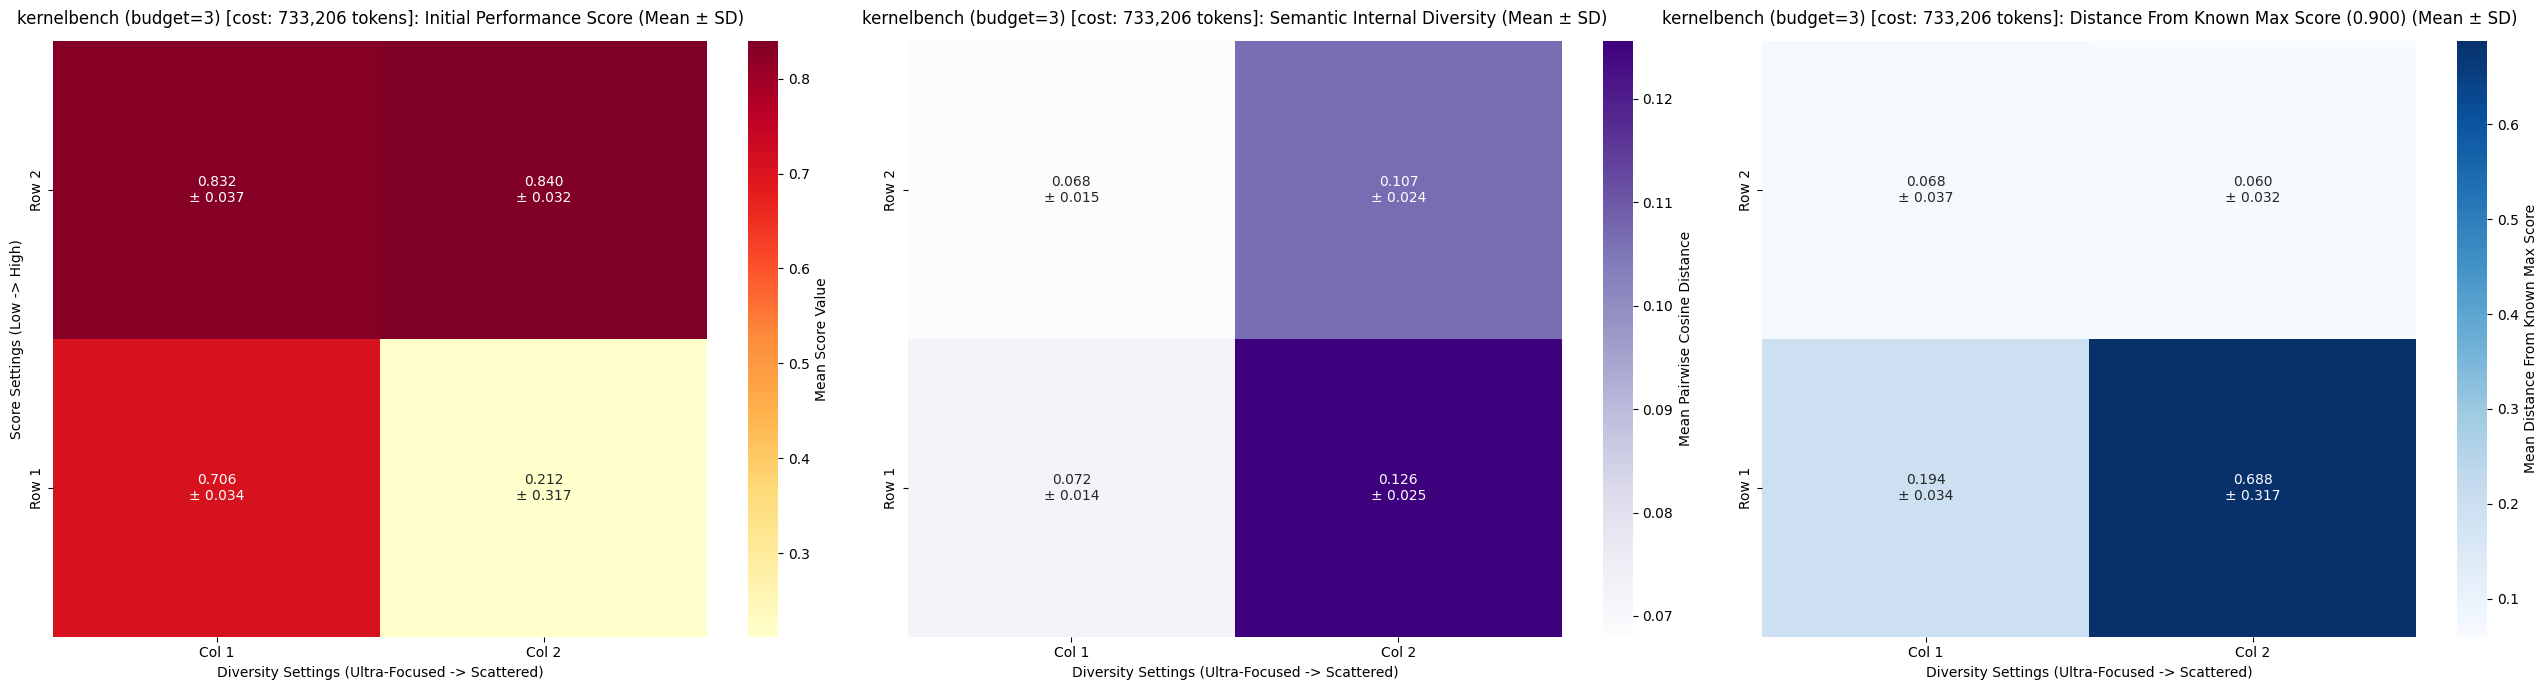


=== kernelbench/budget_10 ===
kernelbench (budget=10): pooled 12 opro run dirs -> 120 rows, 109 unique solutions, 5,250,712 cumulative tokens spent.
kernelbench/budget_10: dropped 12 failed-rollout sentinel score(s).
choose_grid_size: 108 unique solutions -> 4x3 grid (~9 solutions/cell est.)
Pool size after deduplication: 108 solutions.
embed_with_cache[kernelbench_opro_iterbudget]: loaded 108 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/kernelbench_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[kernelbench_opro_iterbudget]: all 108 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 12 populations (grid up to 4x3) using seed 42!


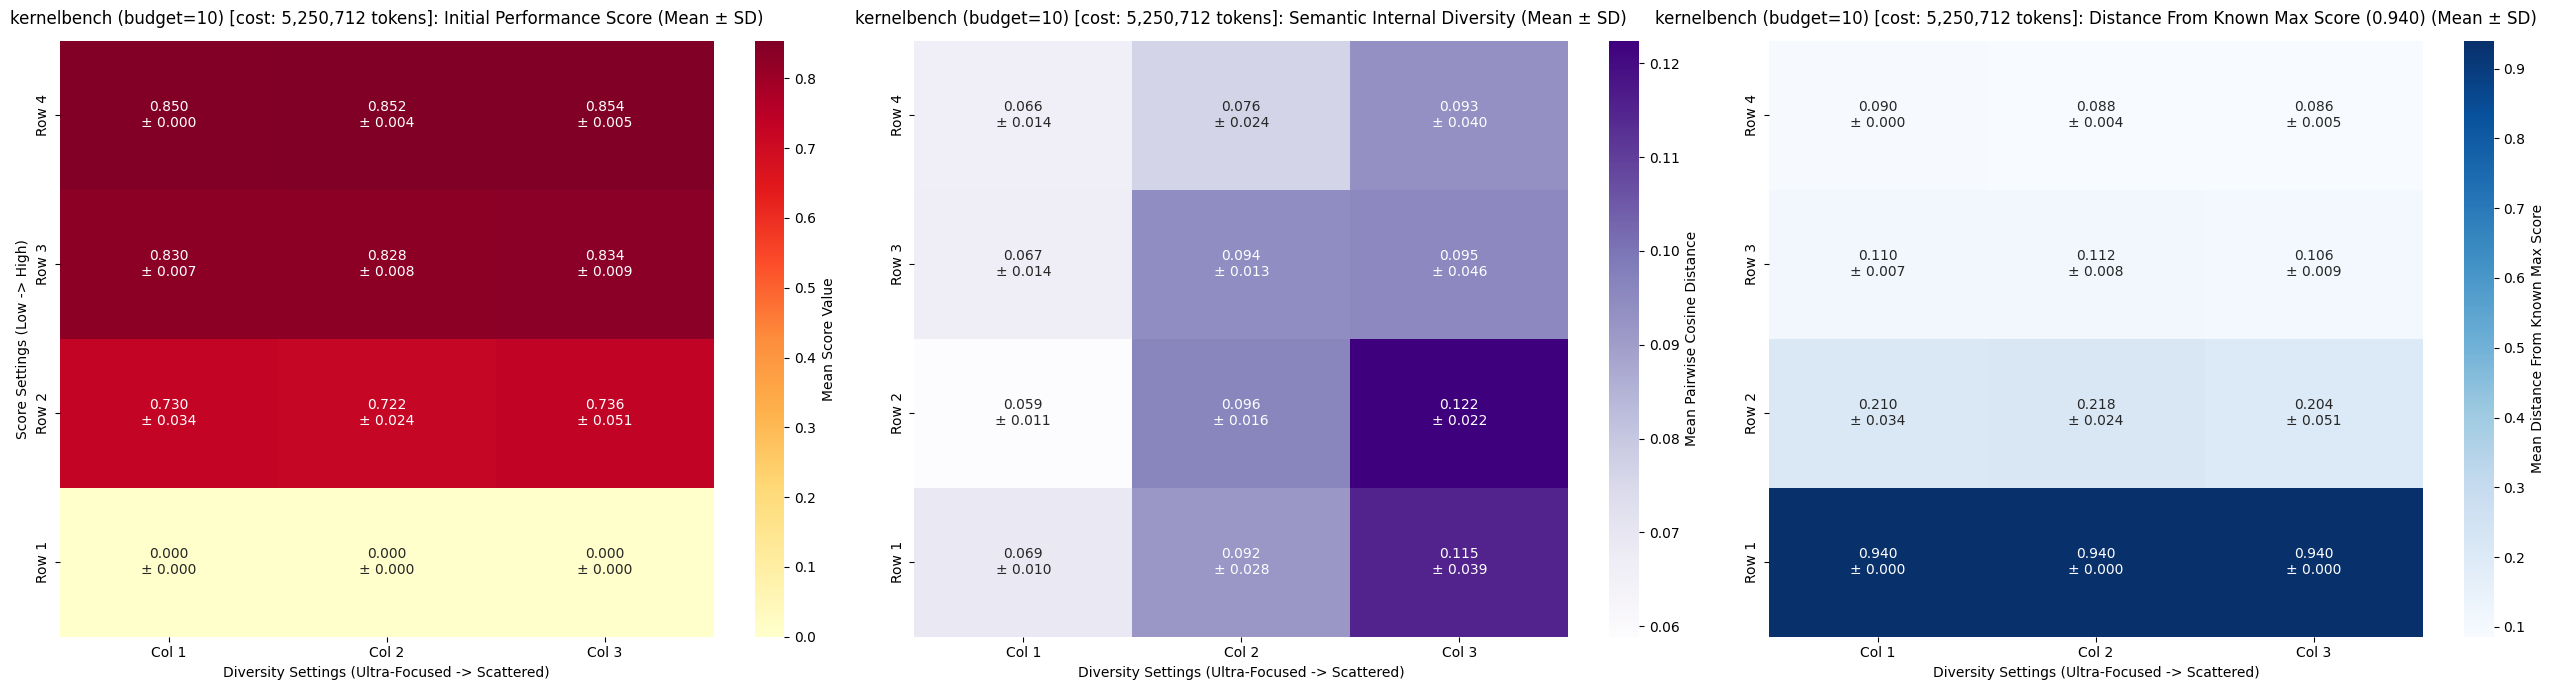


=== cloudcast/budget_1 ===
cloudcast (budget=1): pooled 12 opro run dirs -> 12 rows, 1 unique solutions, 0 cumulative tokens spent.
choose_grid_size: 1 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 1 solutions.
embed_with_cache[cloudcast_opro_iterbudget]: loaded 164 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cloudcast_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cloudcast_opro_iterbudget]: all 1 texts already cached -- skipping model load entirely.
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 2 populations (grid up to 2x2) using seed 42!


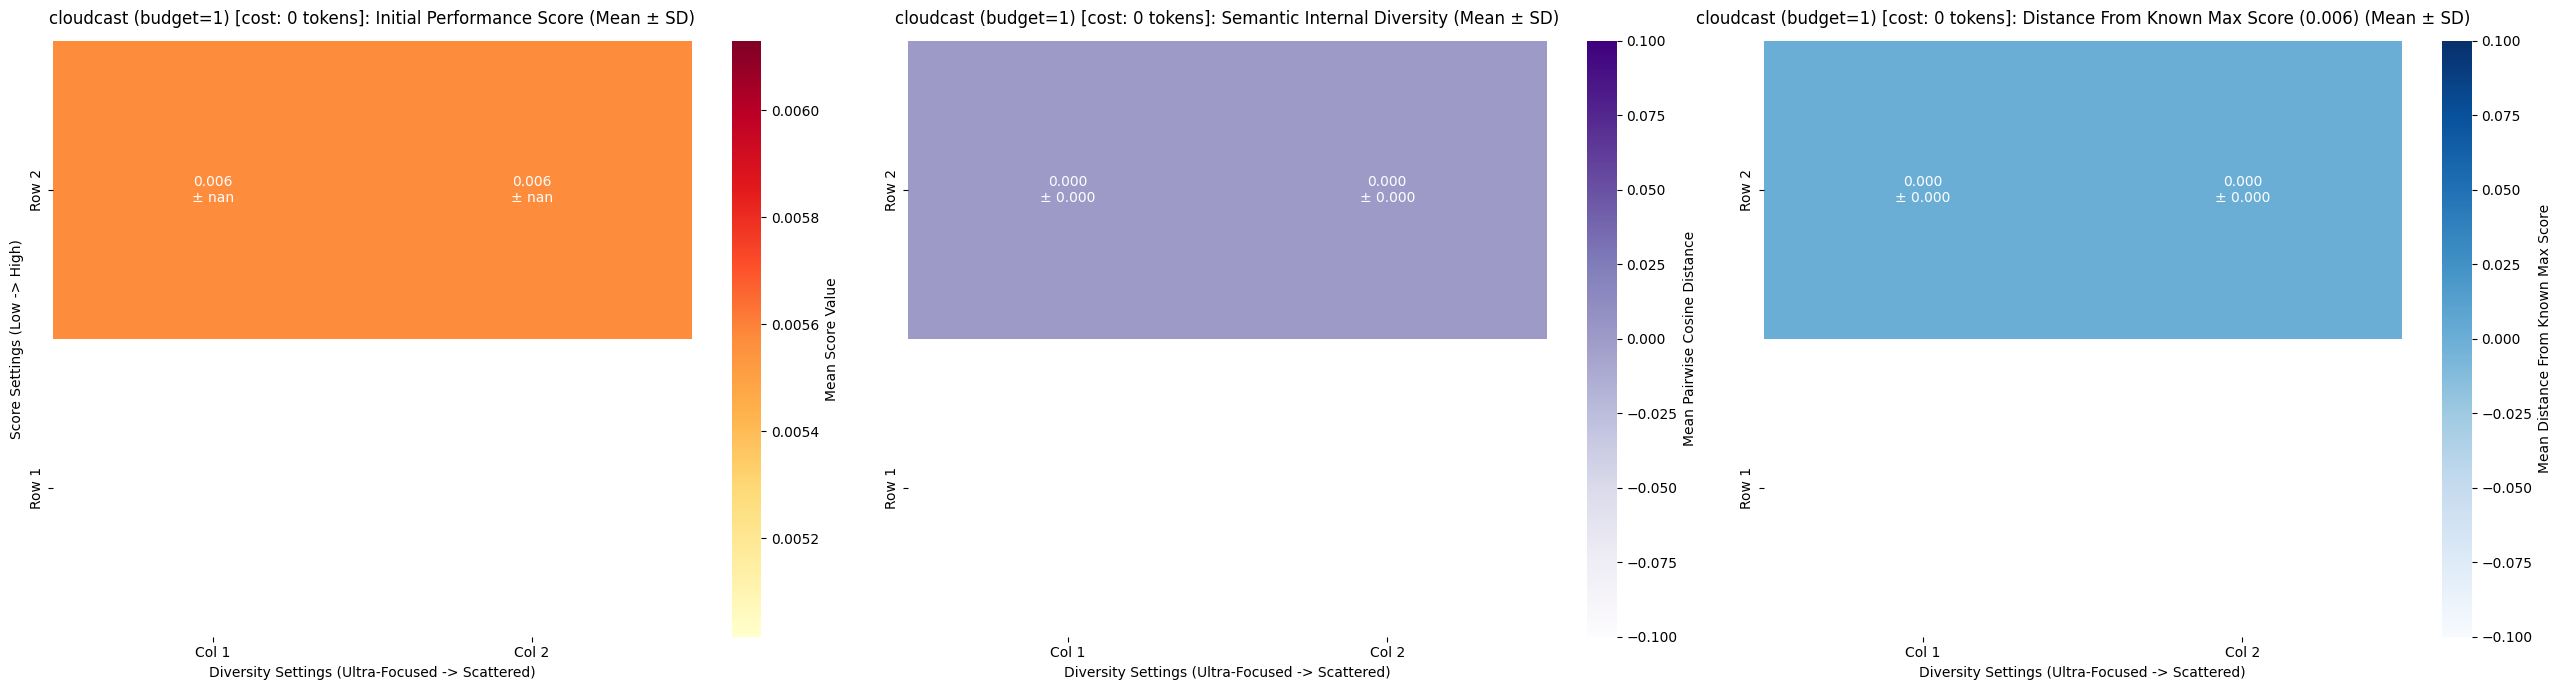


=== cloudcast/budget_2 ===
cloudcast (budget=2): pooled 12 opro run dirs -> 24 rows, 13 unique solutions, 244,658 cumulative tokens spent.
cloudcast/budget_2: dropped 1 failed-rollout sentinel score(s).
choose_grid_size: 12 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 12 solutions.
embed_with_cache[cloudcast_opro_iterbudget]: loaded 164 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cloudcast_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cloudcast_opro_iterbudget]: all 12 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


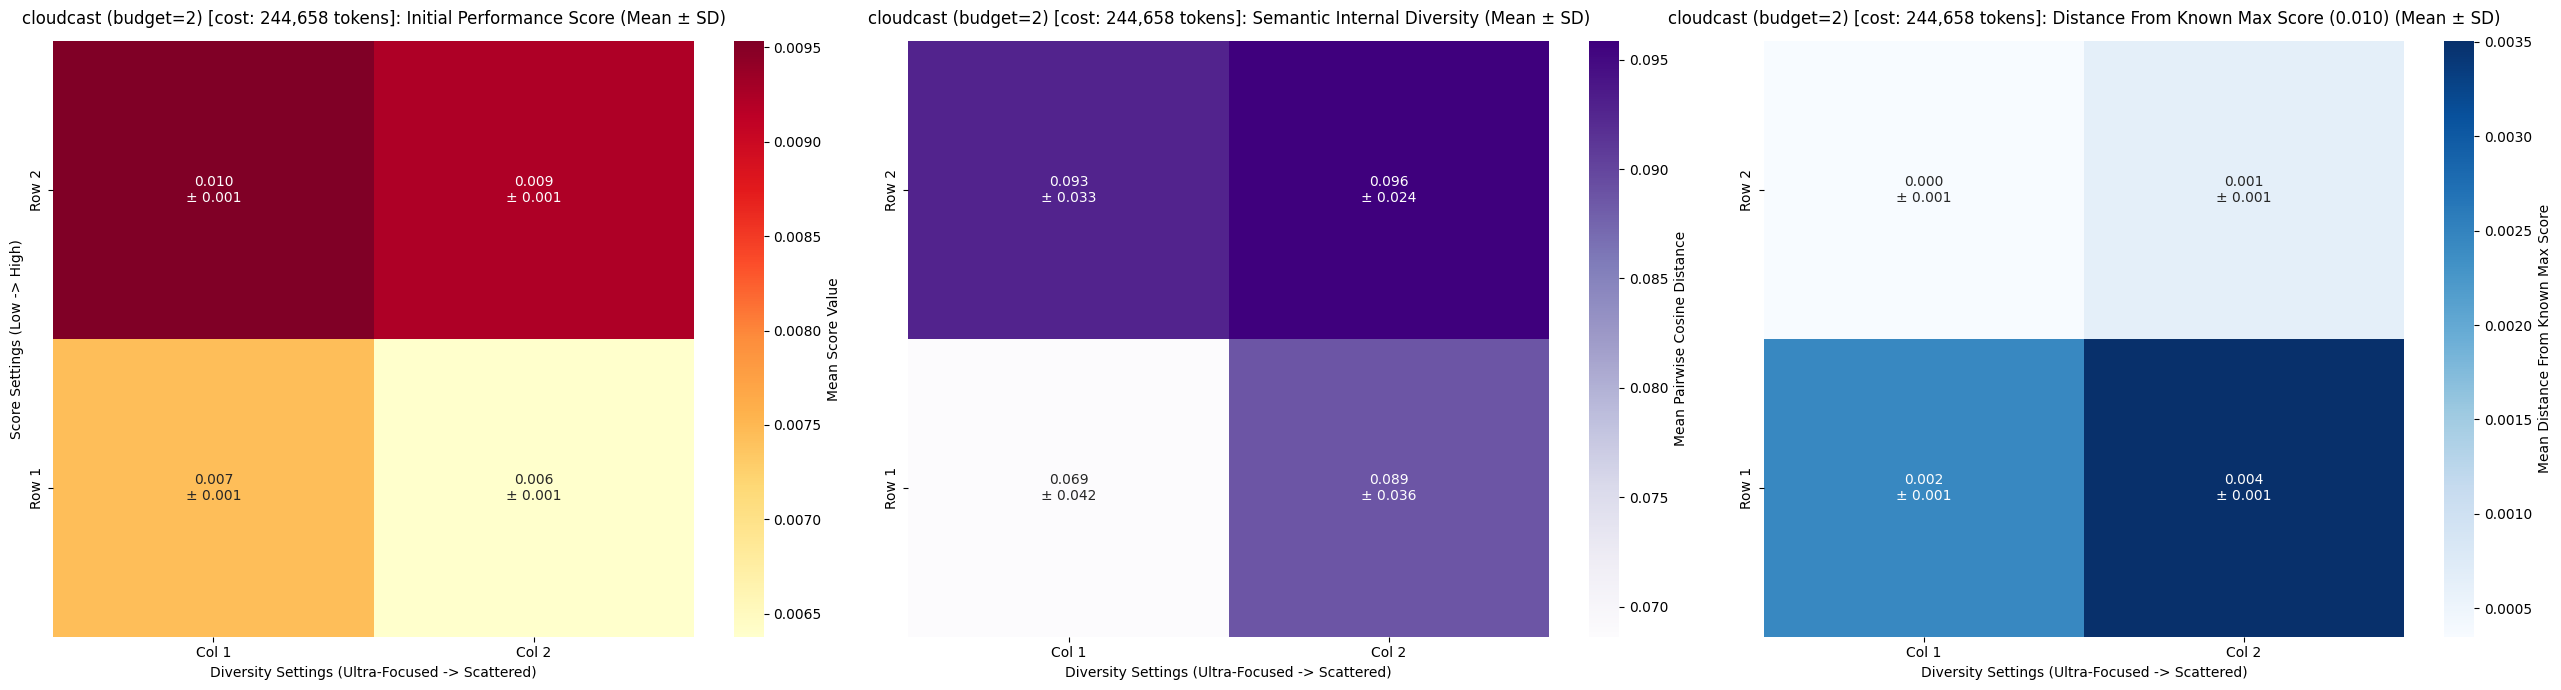


=== cloudcast/budget_3 ===
cloudcast (budget=3): pooled 12 opro run dirs -> 36 rows, 25 unique solutions, 481,719 cumulative tokens spent.
cloudcast/budget_3: dropped 1 failed-rollout sentinel score(s).
choose_grid_size: 24 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 24 solutions.
embed_with_cache[cloudcast_opro_iterbudget]: loaded 164 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cloudcast_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cloudcast_opro_iterbudget]: all 24 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


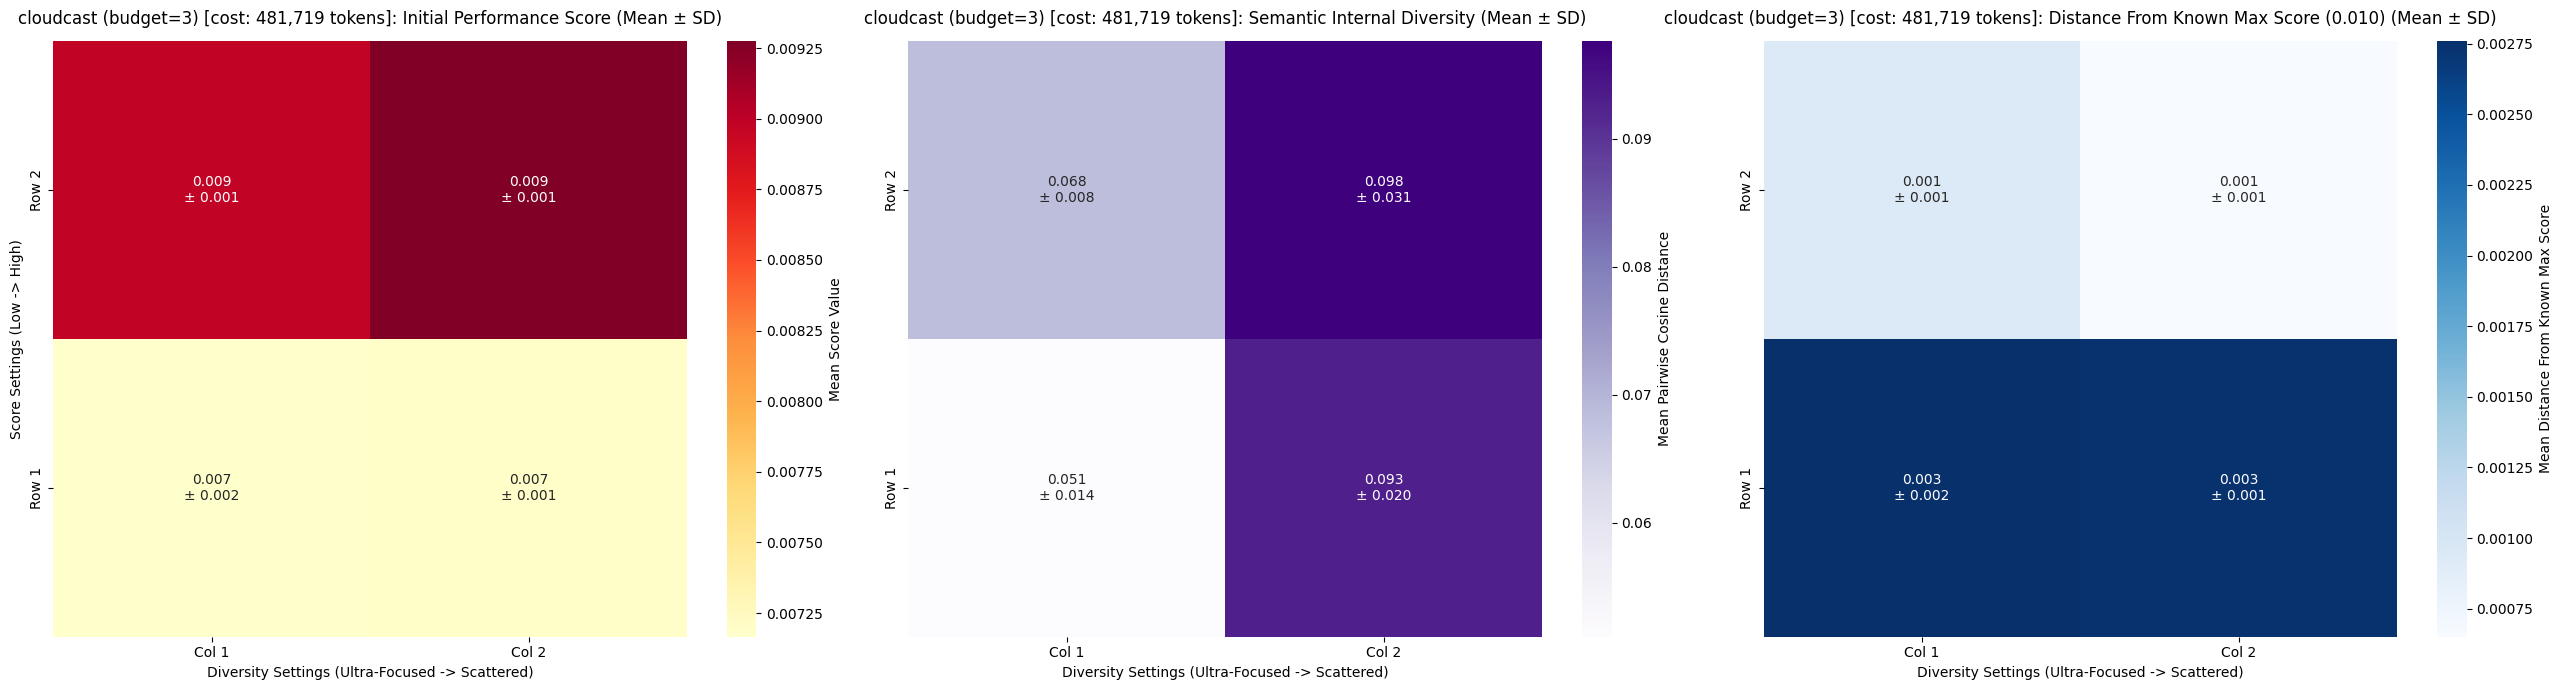


=== cloudcast/budget_10 ===
cloudcast (budget=10): pooled 12 opro run dirs -> 120 rows, 108 unique solutions, 2,670,531 cumulative tokens spent.
cloudcast/budget_10: dropped 3 failed-rollout sentinel score(s).
choose_grid_size: 105 unique solutions -> 4x3 grid (~9 solutions/cell est.)
Pool size after deduplication: 105 solutions.
embed_with_cache[cloudcast_opro_iterbudget]: loaded 164 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cloudcast_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cloudcast_opro_iterbudget]: all 105 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 12 populations (grid up to 4x3) using seed 42!


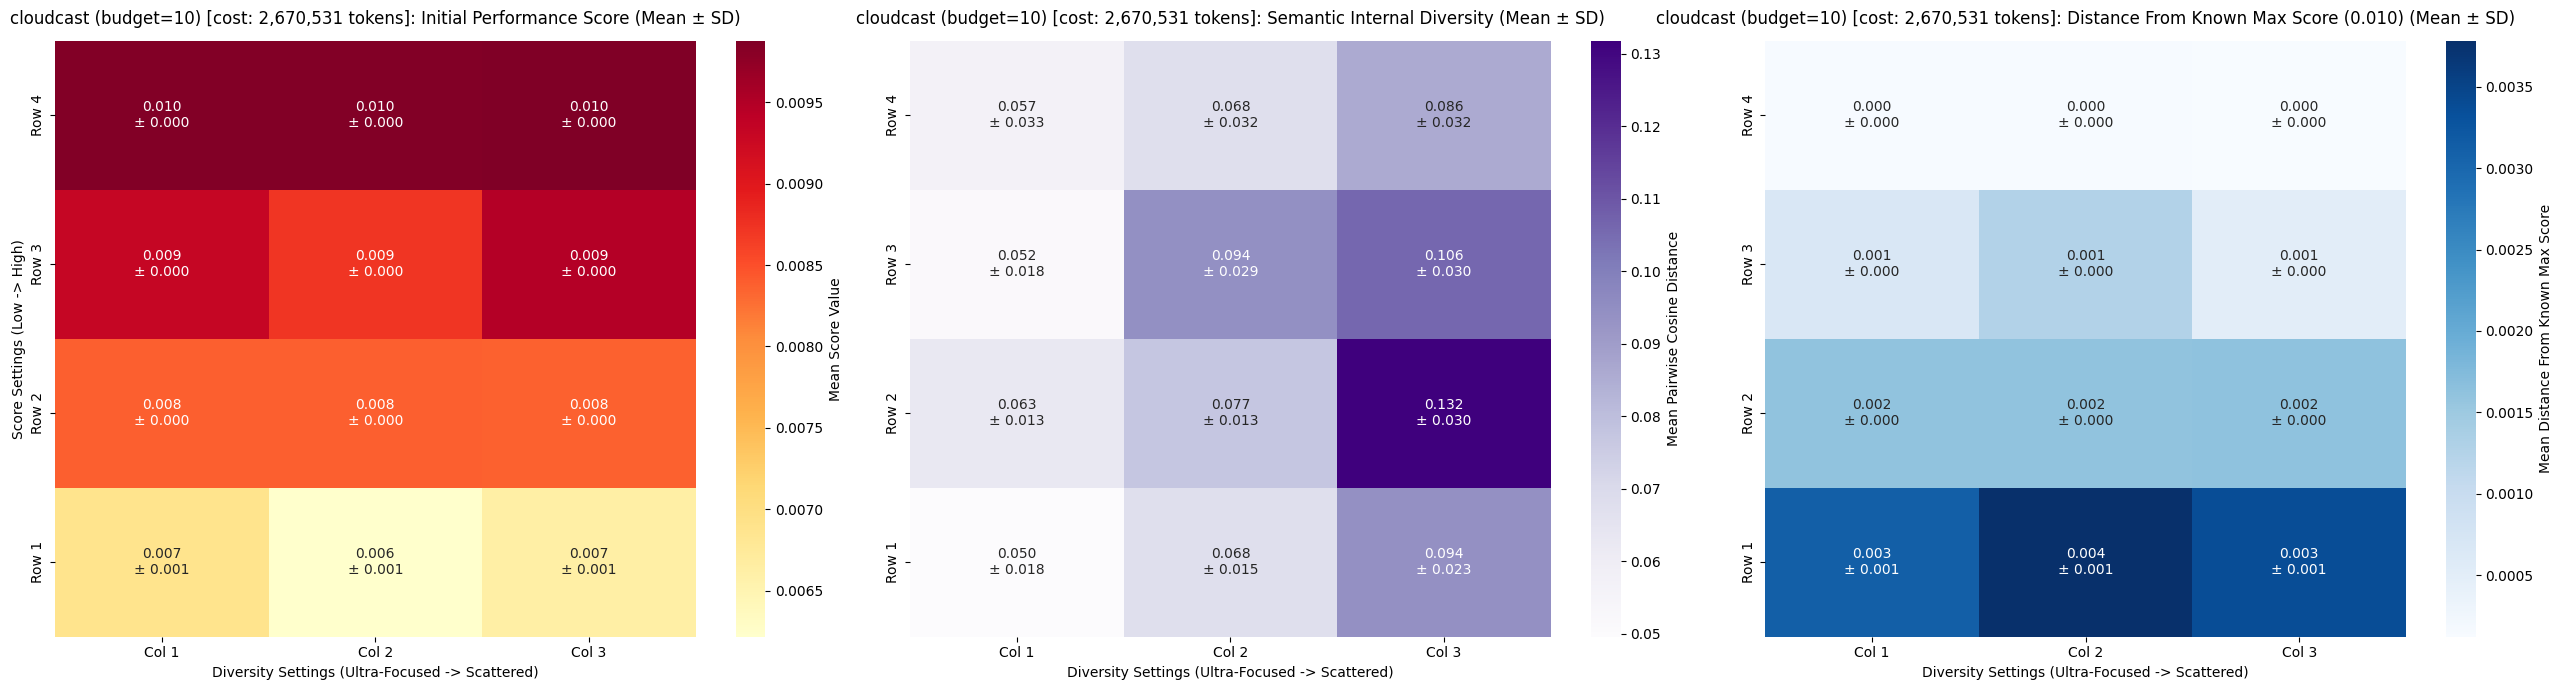


=== cantbelate/budget_2 ===
cantbelate (budget=2): pooled 12 opro run dirs -> 24 rows, 13 unique solutions, 254,782 cumulative tokens spent.
choose_grid_size: 13 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 13 solutions.
embed_with_cache[cantbelate_opro_iterbudget]: loaded 798 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cantbelate_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cantbelate_opro_iterbudget]: all 13 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
 Variance Alert: Row_2_Col_1 couldn't easily find SD < 0.05. Forcing closest scores.
Row_2_Col_1
 Variance Alert: Row_2_Col_2 couldn't easily find SD < 0.05. Forcing closest scores.
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


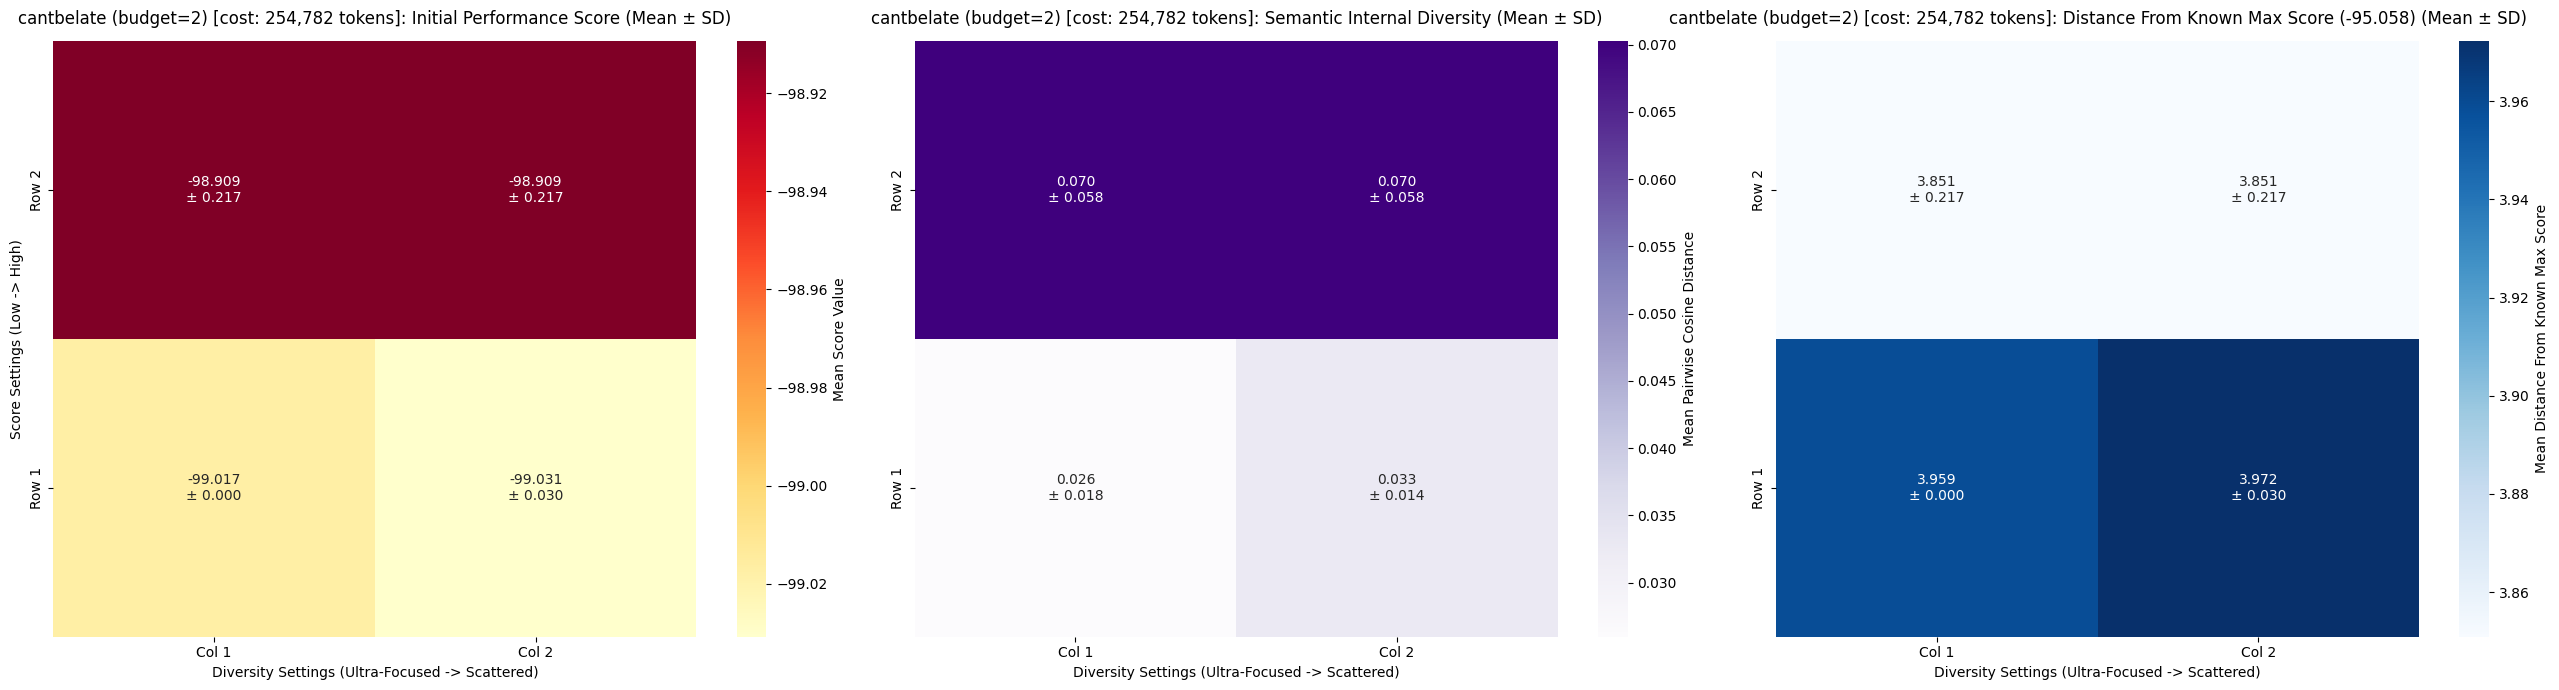


=== cantbelate/budget_3 ===
cantbelate (budget=3): pooled 12 opro run dirs -> 36 rows, 25 unique solutions, 546,723 cumulative tokens spent.
choose_grid_size: 25 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 25 solutions.
embed_with_cache[cantbelate_opro_iterbudget]: loaded 798 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cantbelate_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cantbelate_opro_iterbudget]: all 25 texts already cached -- skipping model load entirely.
 Variance Alert: Row_1_Col_1 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_1
 Variance Alert: Row_1_Col_2 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_2
 Variance Alert: Row_2_Col_1 couldn't easily find SD < 0.05. Forcing closest scores.
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using s

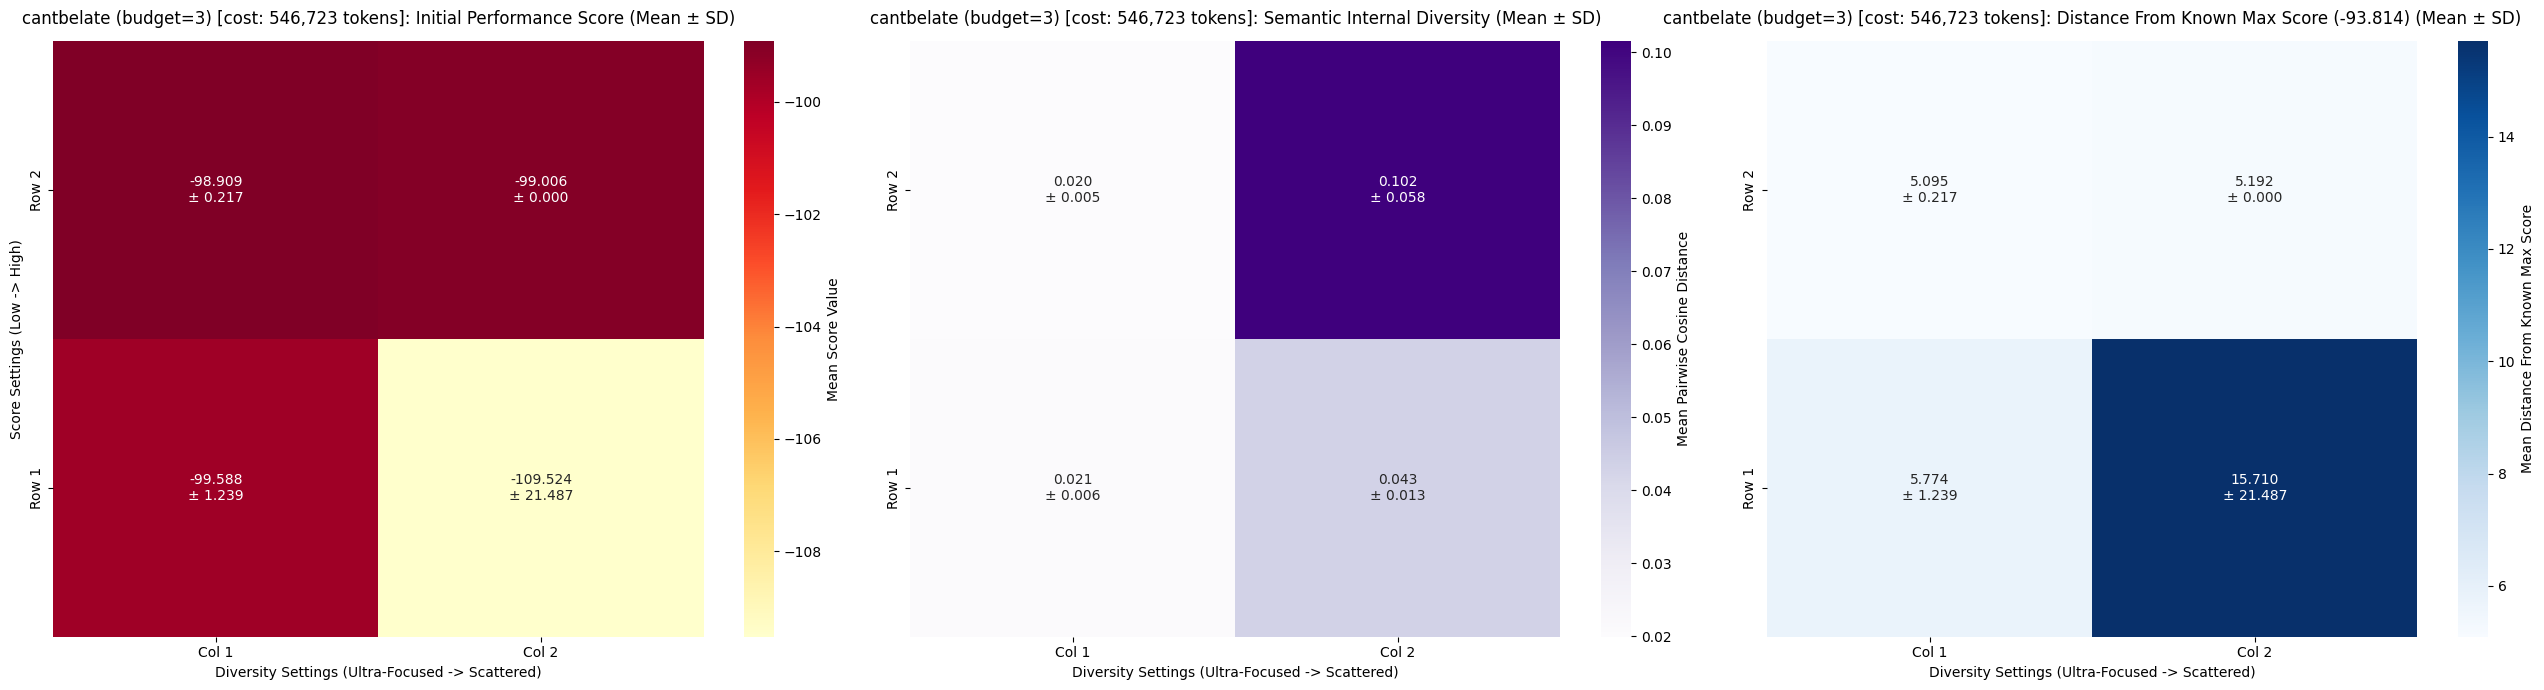


=== cantbelate/budget_10 ===
cantbelate (budget=10): pooled 12 opro run dirs -> 120 rows, 109 unique solutions, 2,318,280 cumulative tokens spent.
cantbelate/budget_10: dropped 2 failed-rollout sentinel score(s).
choose_grid_size: 107 unique solutions -> 4x3 grid (~9 solutions/cell est.)
Pool size after deduplication: 107 solutions.
embed_with_cache[cantbelate_opro_iterbudget]: loaded 798 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cantbelate_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cantbelate_opro_iterbudget]: all 107 texts already cached -- skipping model load entirely.
 Variance Alert: Row_1_Col_1 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_1
 Variance Alert: Row_1_Col_2 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_2
 Variance Alert: Row_1_Col_3 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
 Variance

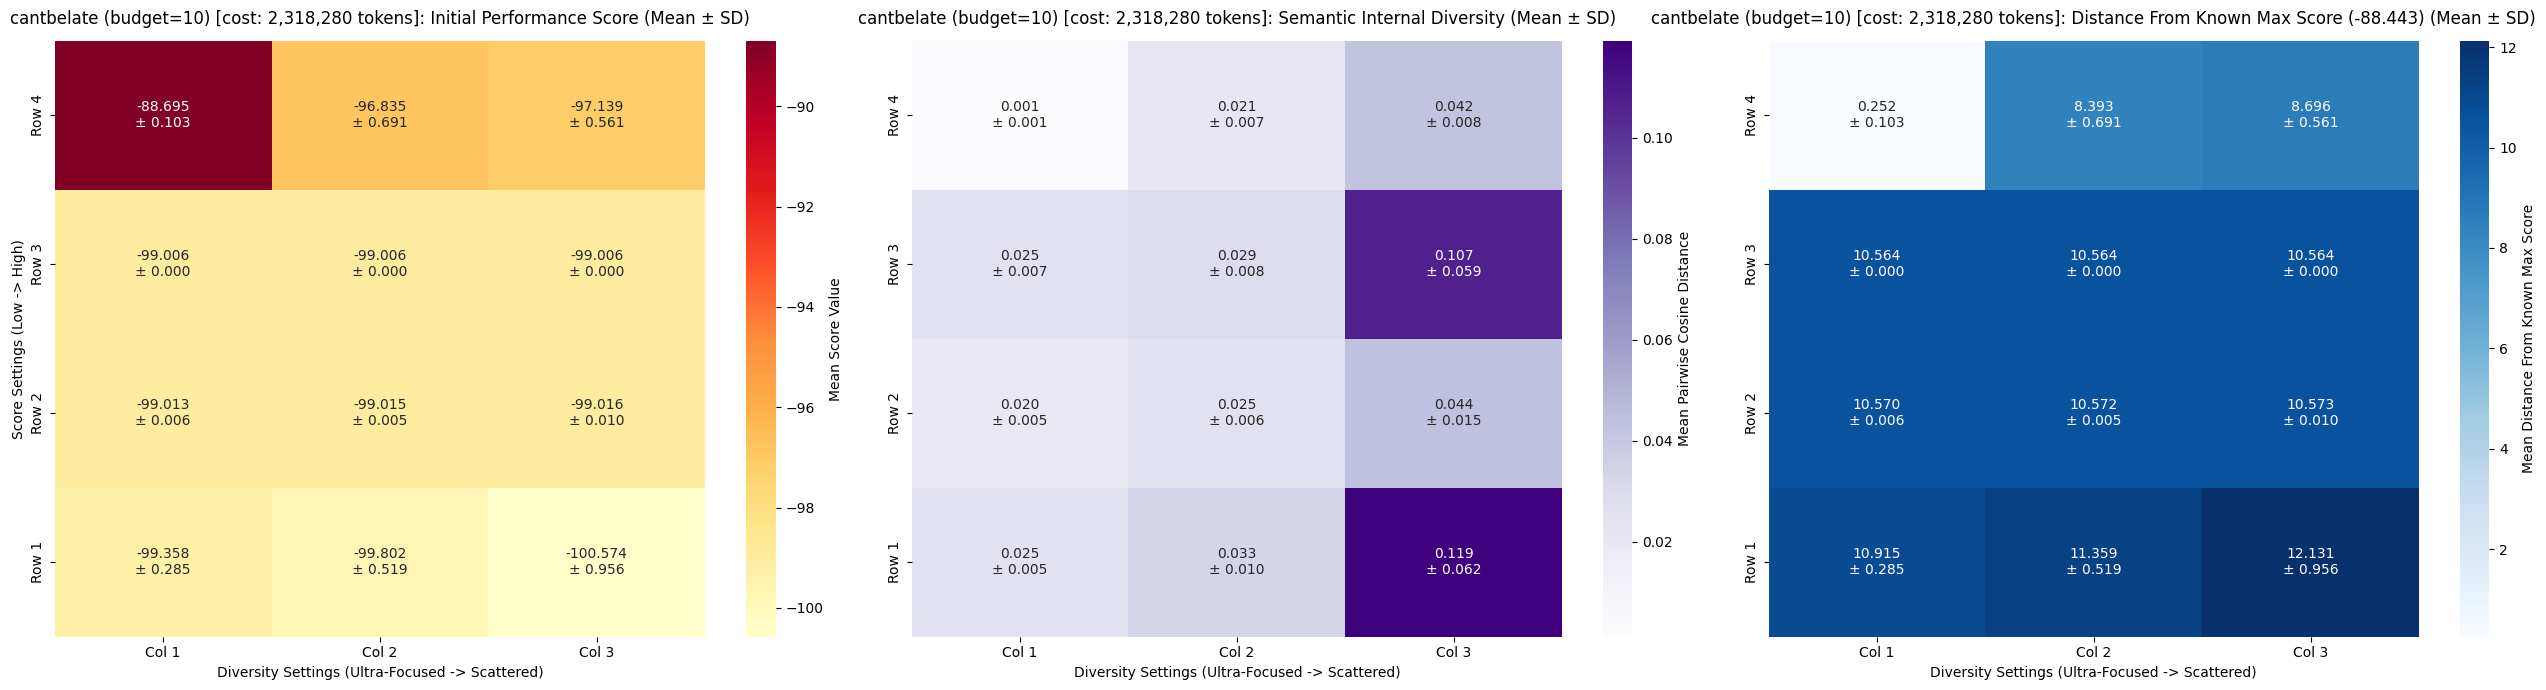


=== cantbelate/budget_50 ===
cantbelate (budget=50): pooled 12 opro run dirs -> 600 rows, 566 unique solutions, 11,662,138 cumulative tokens spent.
cantbelate/budget_50: dropped 4 failed-rollout sentinel score(s).
choose_grid_size: 562 unique solutions -> 4x3 grid (~47 solutions/cell est.)
Pool size after deduplication: 562 solutions.
embed_with_cache[cantbelate_opro_iterbudget]: loaded 798 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cantbelate_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cantbelate_opro_iterbudget]: all 562 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 12 populations (grid up to 4x3) using seed 42!


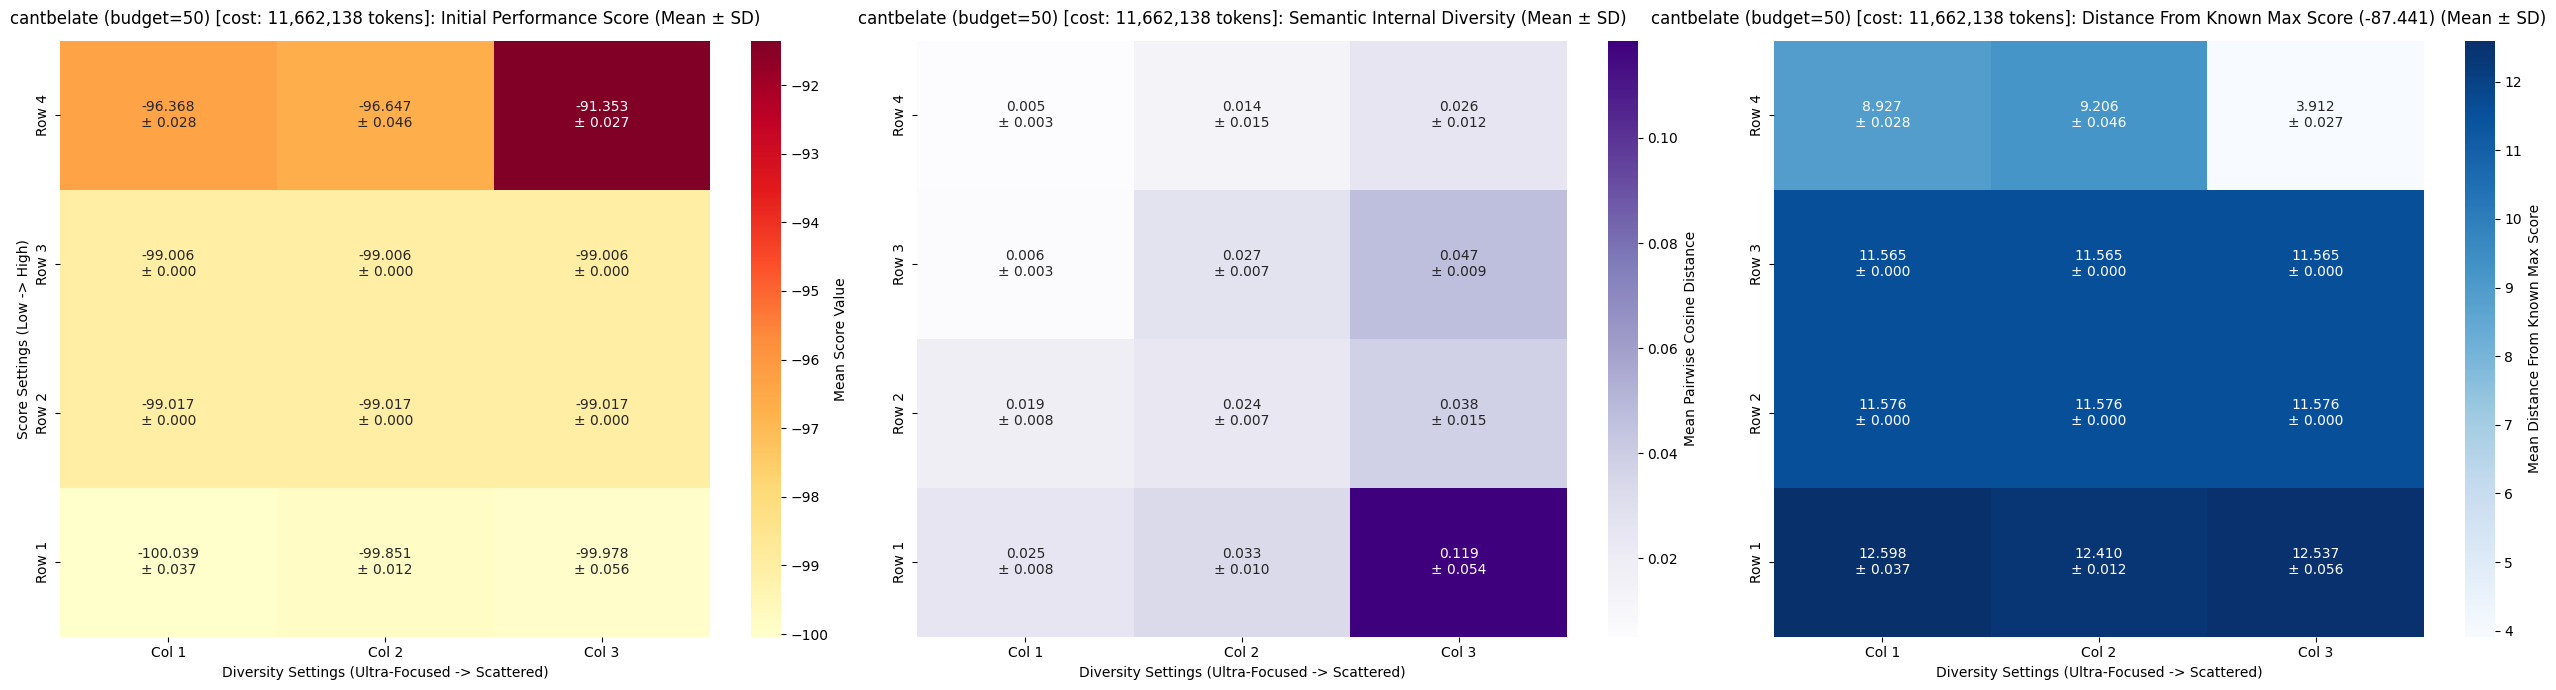


=== harmbench/budget_2 ===
harmbench (budget=2): pooled 12 opro run dirs -> 24 rows, 13 unique solutions, 4,646 cumulative tokens spent.
choose_grid_size: 13 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 13 solutions.
embed_with_cache[harmbench_opro_iterbudget]: loaded 589 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/harmbench_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[harmbench_opro_iterbudget]: all 13 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


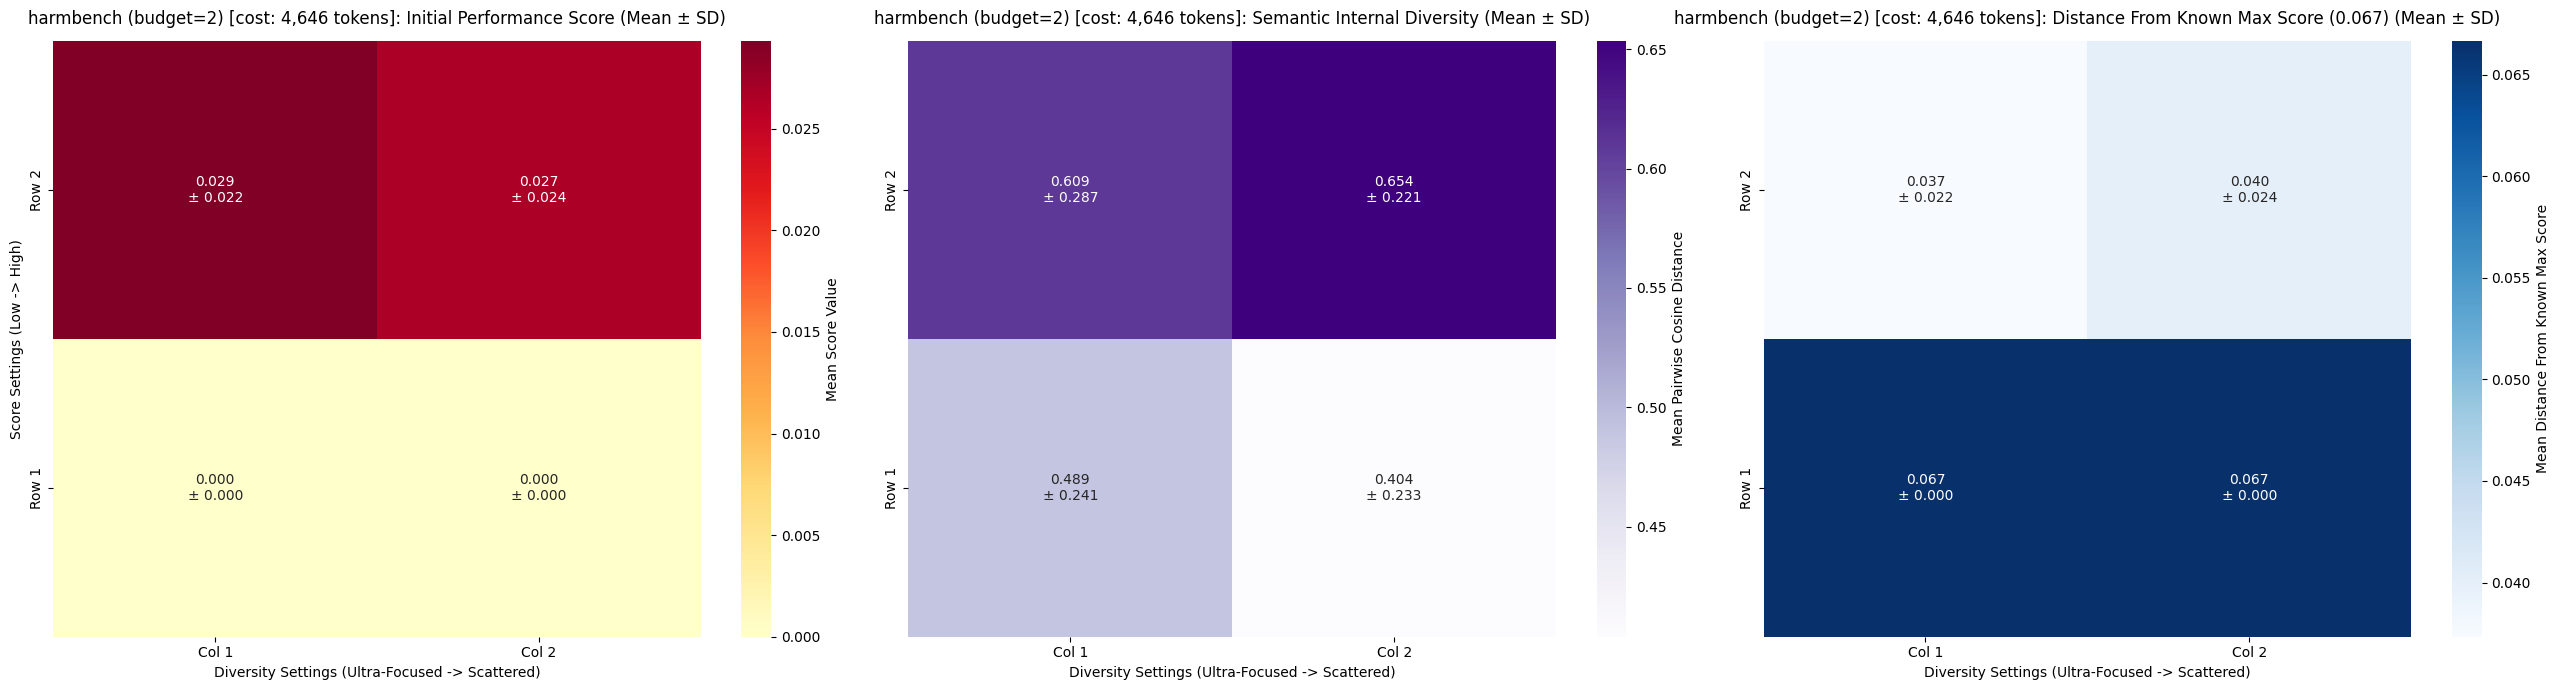


=== harmbench/budget_3 ===
harmbench (budget=3): pooled 12 opro run dirs -> 36 rows, 25 unique solutions, 10,109 cumulative tokens spent.
choose_grid_size: 25 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 25 solutions.
embed_with_cache[harmbench_opro_iterbudget]: loaded 589 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/harmbench_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[harmbench_opro_iterbudget]: all 25 texts already cached -- skipping model load entirely.
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 2 populations (grid up to 2x2) using seed 42!


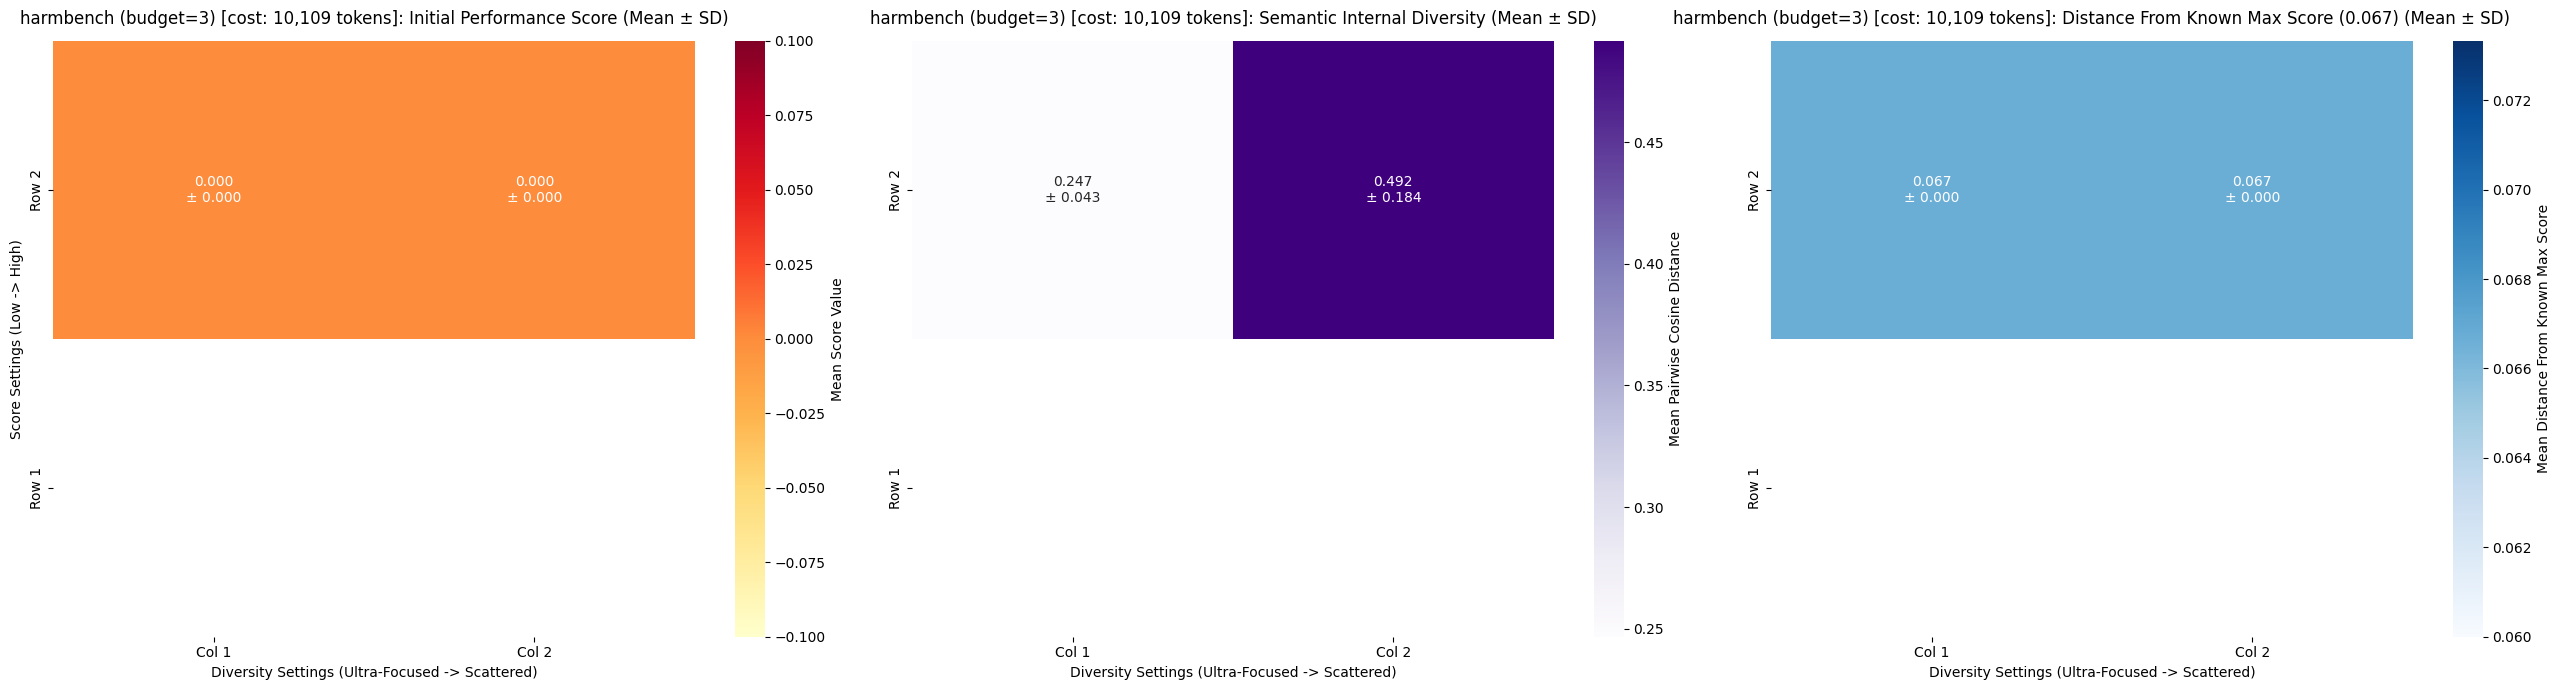


=== harmbench/budget_5 ===
harmbench (budget=5): pooled 12 opro run dirs -> 60 rows, 49 unique solutions, 34,167 cumulative tokens spent.
choose_grid_size: 49 unique solutions -> 2x2 grid (~12 solutions/cell est.)
Pool size after deduplication: 49 solutions.
embed_with_cache[harmbench_opro_iterbudget]: loaded 589 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/harmbench_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[harmbench_opro_iterbudget]: all 49 texts already cached -- skipping model load entirely.
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 2 populations (grid up to 2x2) using seed 42!


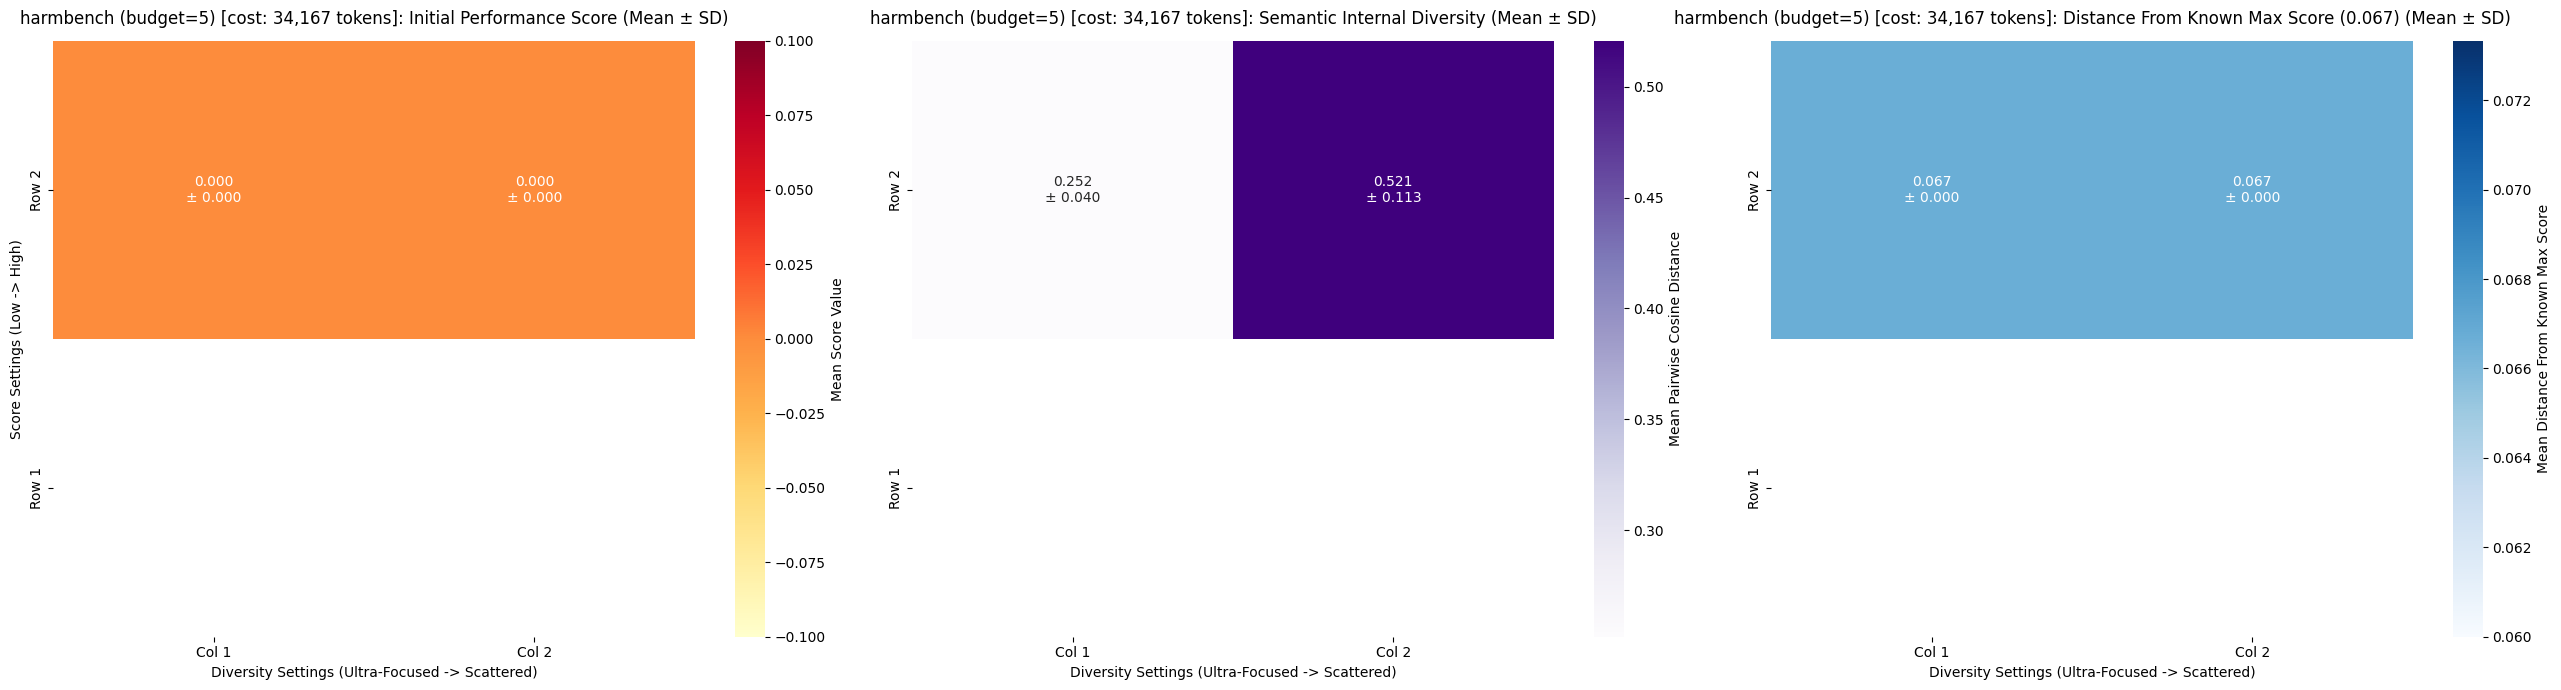


=== harmbench/budget_10 ===
harmbench (budget=10): pooled 12 opro run dirs -> 120 rows, 109 unique solutions, 95,326 cumulative tokens spent.
choose_grid_size: 109 unique solutions -> 4x3 grid (~9 solutions/cell est.)
Pool size after deduplication: 109 solutions.
embed_with_cache[harmbench_opro_iterbudget]: loaded 589 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/harmbench_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[harmbench_opro_iterbudget]: all 109 texts already cached -- skipping model load entirely.
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 6 populations (grid up to 4x3) using seed 42!


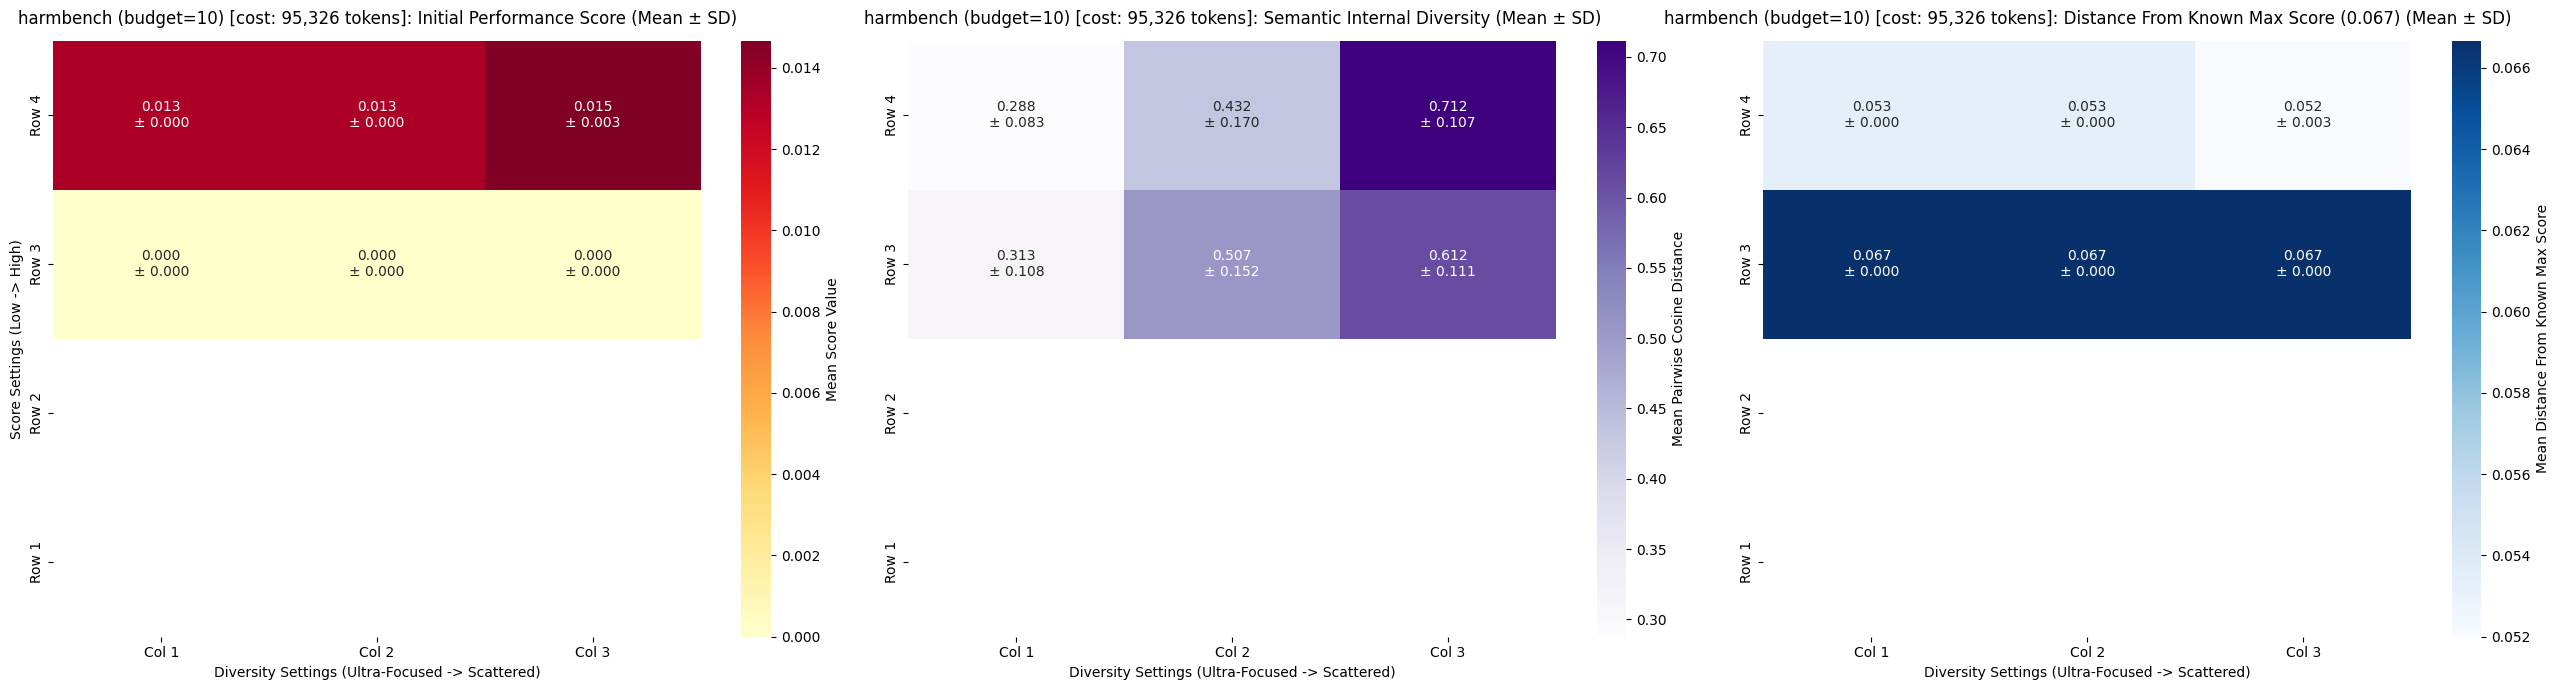


=== harmbench/budget_50 ===
harmbench (budget=50): pooled 12 opro run dirs -> 600 rows, 589 unique solutions, 577,081 cumulative tokens spent.
choose_grid_size: 589 unique solutions -> 4x3 grid (~49 solutions/cell est.)
Pool size after deduplication: 589 solutions.
embed_with_cache[harmbench_opro_iterbudget]: loaded 589 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/harmbench_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[harmbench_opro_iterbudget]: all 589 texts already cached -- skipping model load entirely.
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 9 populations (grid up to 4x3) using seed 42!


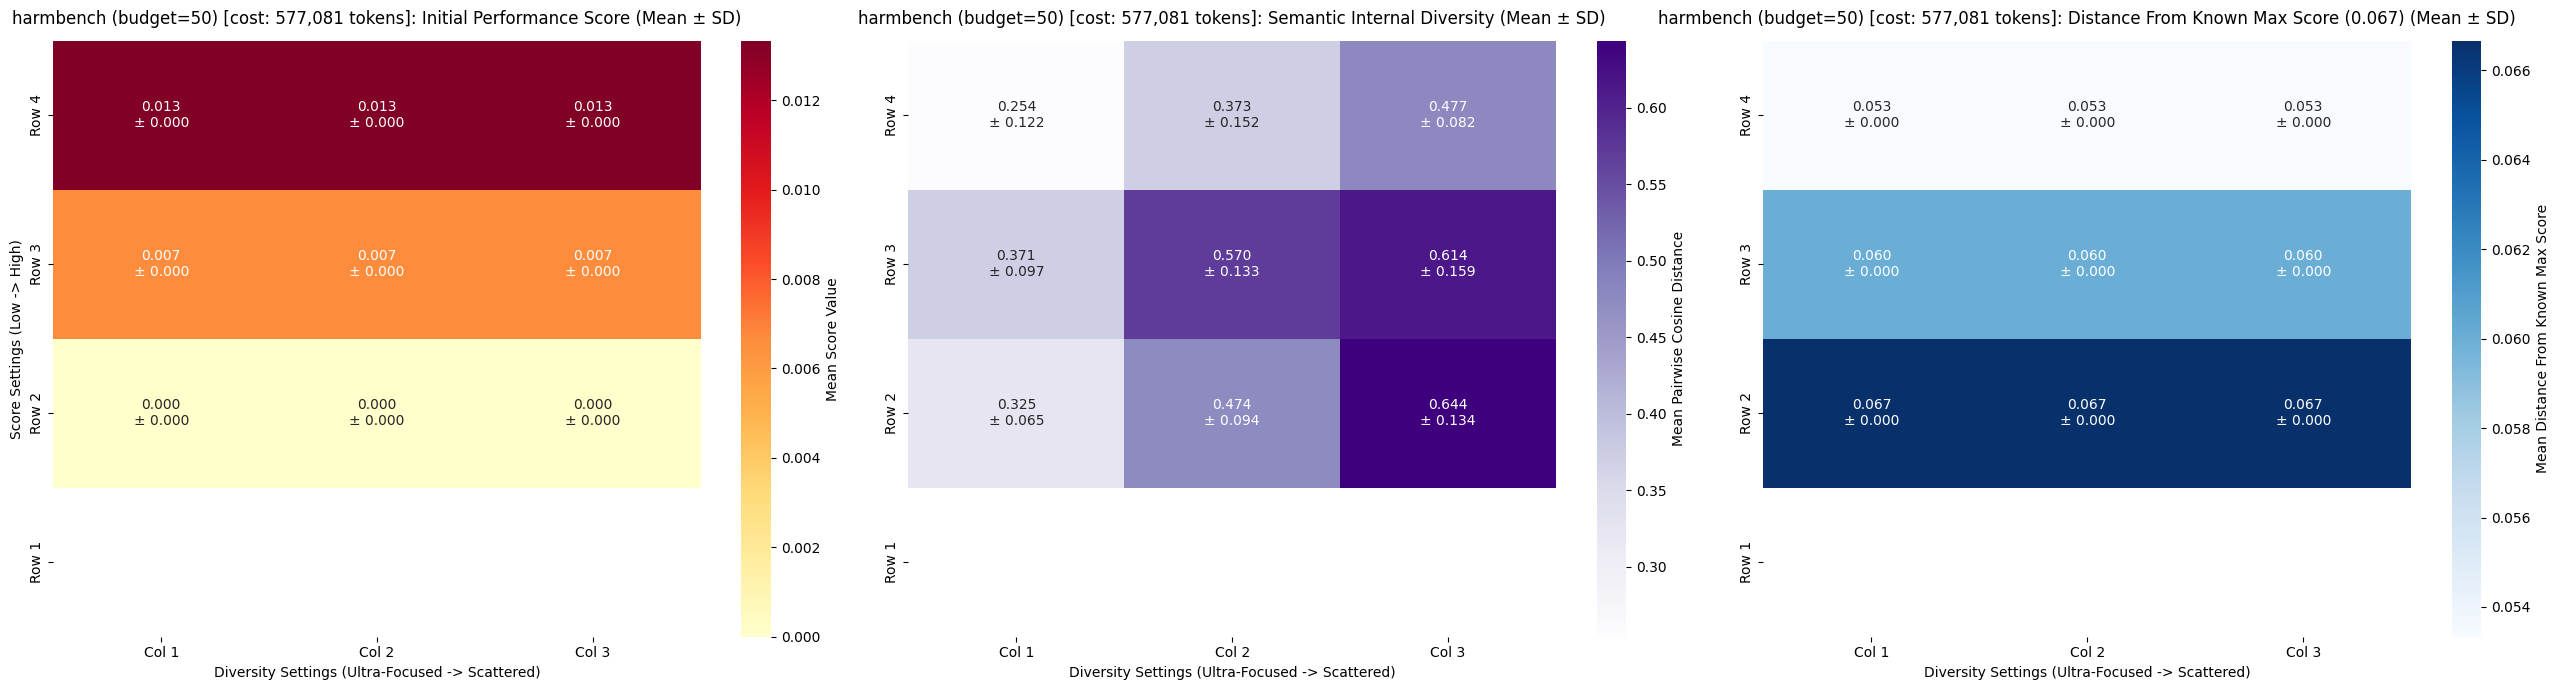


=== prompt_gsm8k/budget_2 ===
prompt/gsm8k (budget=2): pooled 12 opro run dirs -> 24 rows, 13 unique solutions, 16,788 cumulative tokens spent.
choose_grid_size: 13 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 13 solutions.
embed_with_cache[prompt_gsm8k_opro_iterbudget]: loaded 518 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_gsm8k_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_gsm8k_opro_iterbudget]: all 13 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


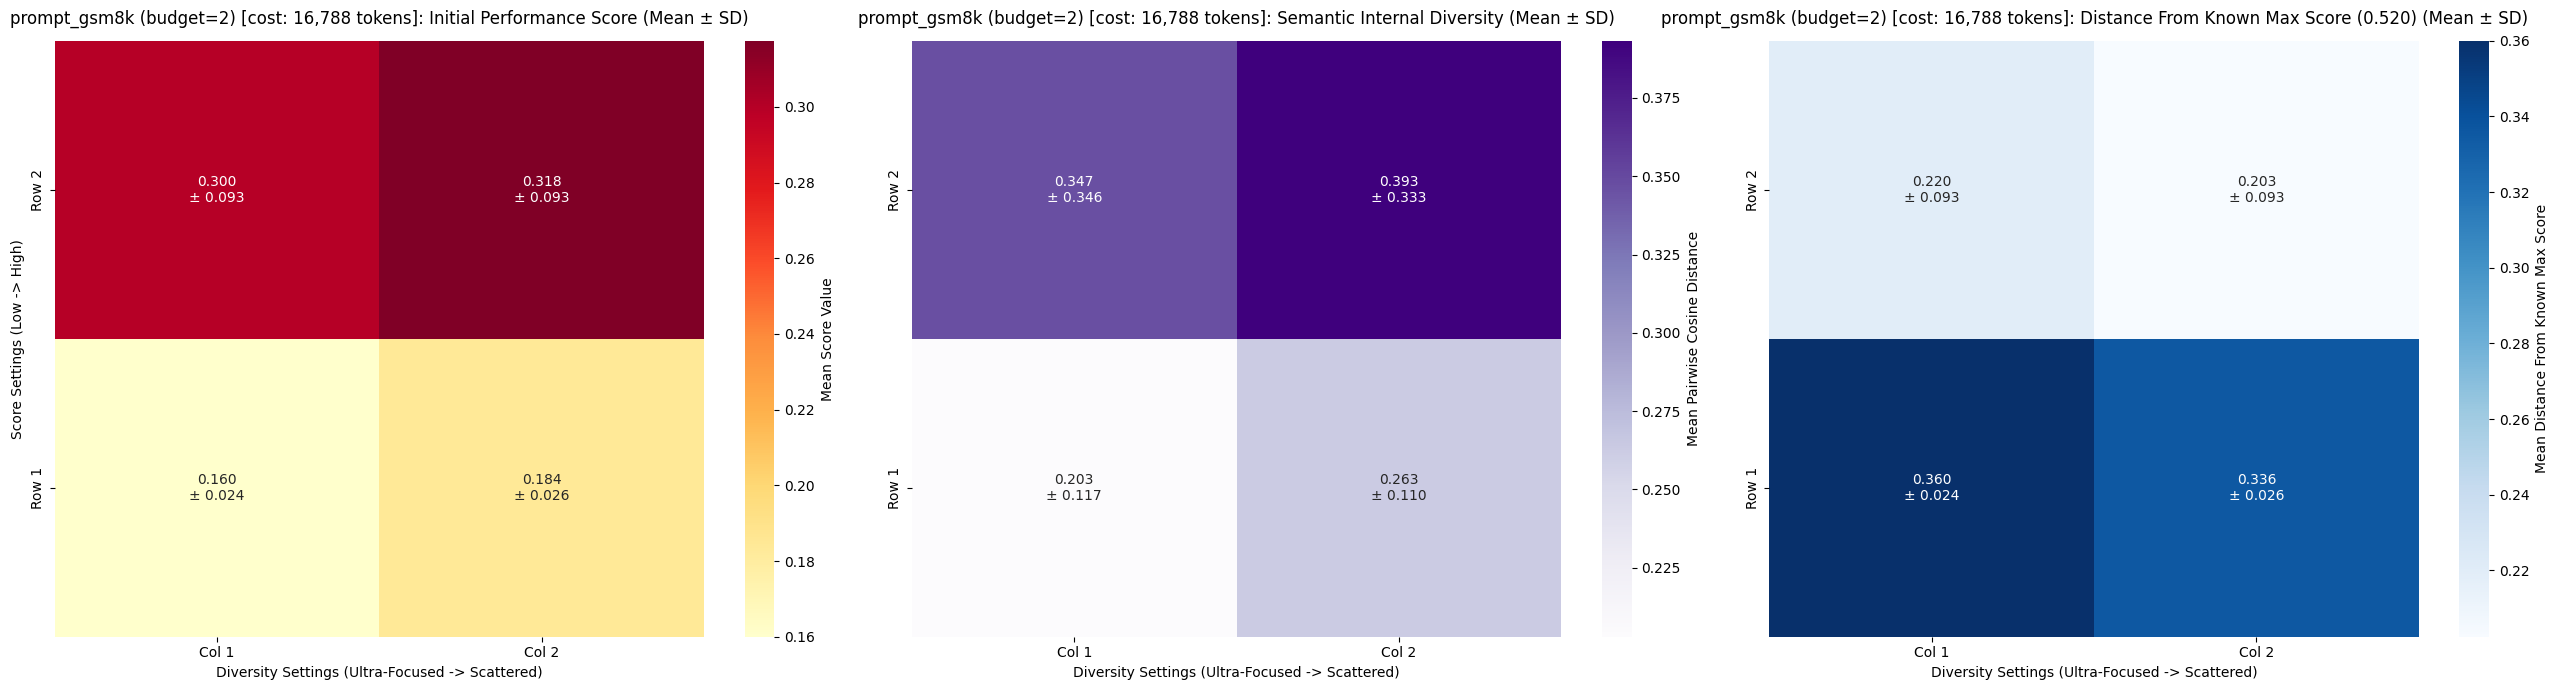


=== prompt_gsm8k/budget_3 ===
prompt/gsm8k (budget=3): pooled 12 opro run dirs -> 36 rows, 24 unique solutions, 40,016 cumulative tokens spent.
choose_grid_size: 24 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 24 solutions.
embed_with_cache[prompt_gsm8k_opro_iterbudget]: loaded 518 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_gsm8k_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_gsm8k_opro_iterbudget]: all 24 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


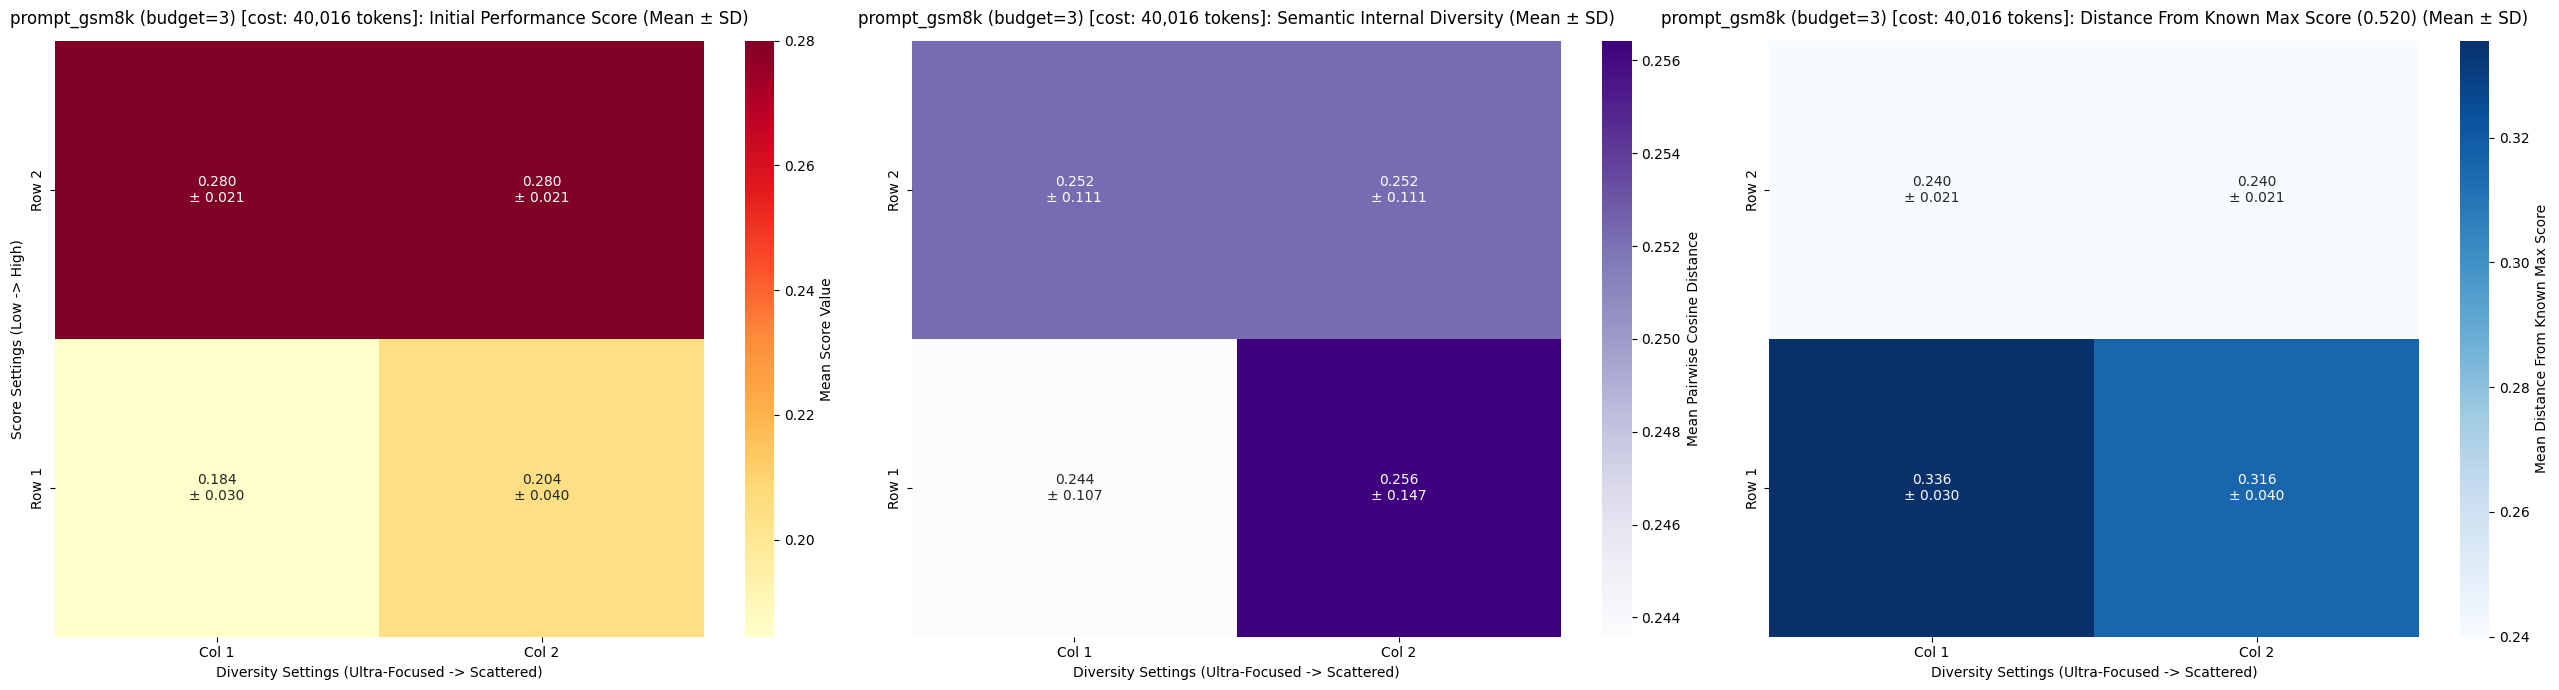


=== prompt_gsm8k/budget_5 ===
prompt/gsm8k (budget=5): pooled 12 opro run dirs -> 60 rows, 47 unique solutions, 93,695 cumulative tokens spent.
choose_grid_size: 47 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 47 solutions.
embed_with_cache[prompt_gsm8k_opro_iterbudget]: loaded 518 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_gsm8k_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_gsm8k_opro_iterbudget]: all 47 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


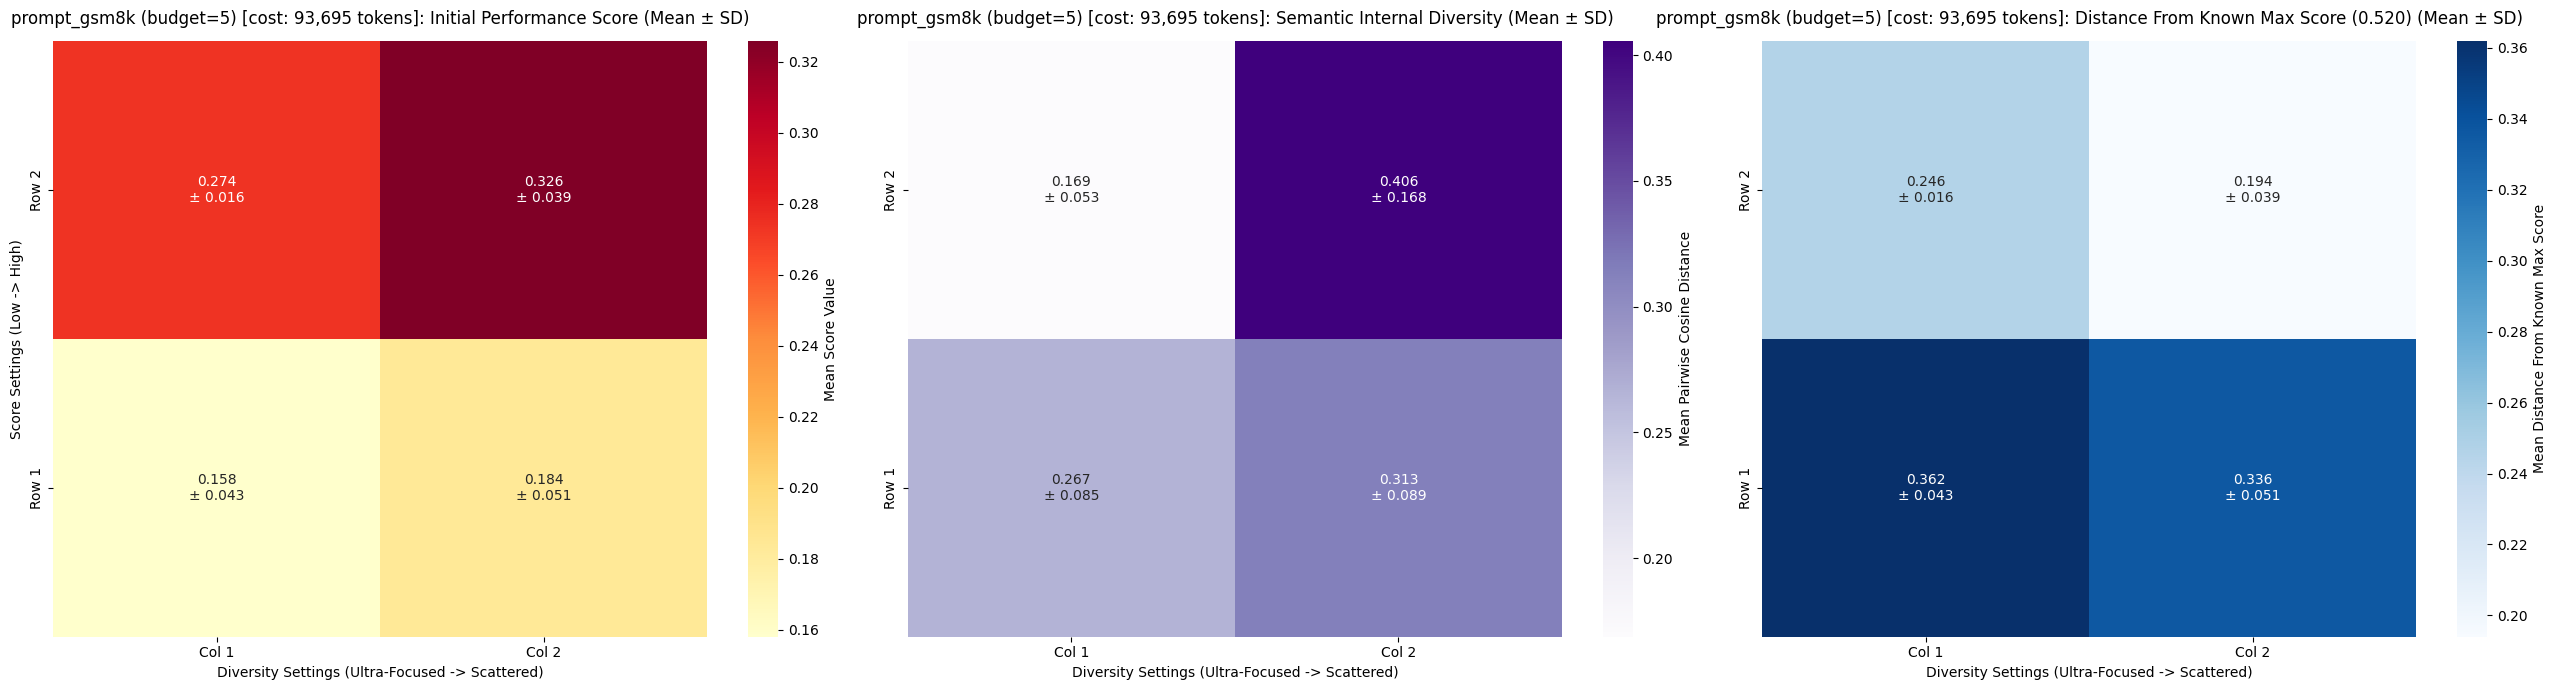


=== prompt_gsm8k/budget_10 ===
prompt/gsm8k (budget=10): pooled 12 opro run dirs -> 120 rows, 101 unique solutions, 238,005 cumulative tokens spent.
choose_grid_size: 101 unique solutions -> 2x2 grid (~25 solutions/cell est.)
Pool size after deduplication: 101 solutions.
embed_with_cache[prompt_gsm8k_opro_iterbudget]: loaded 518 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_gsm8k_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_gsm8k_opro_iterbudget]: all 101 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


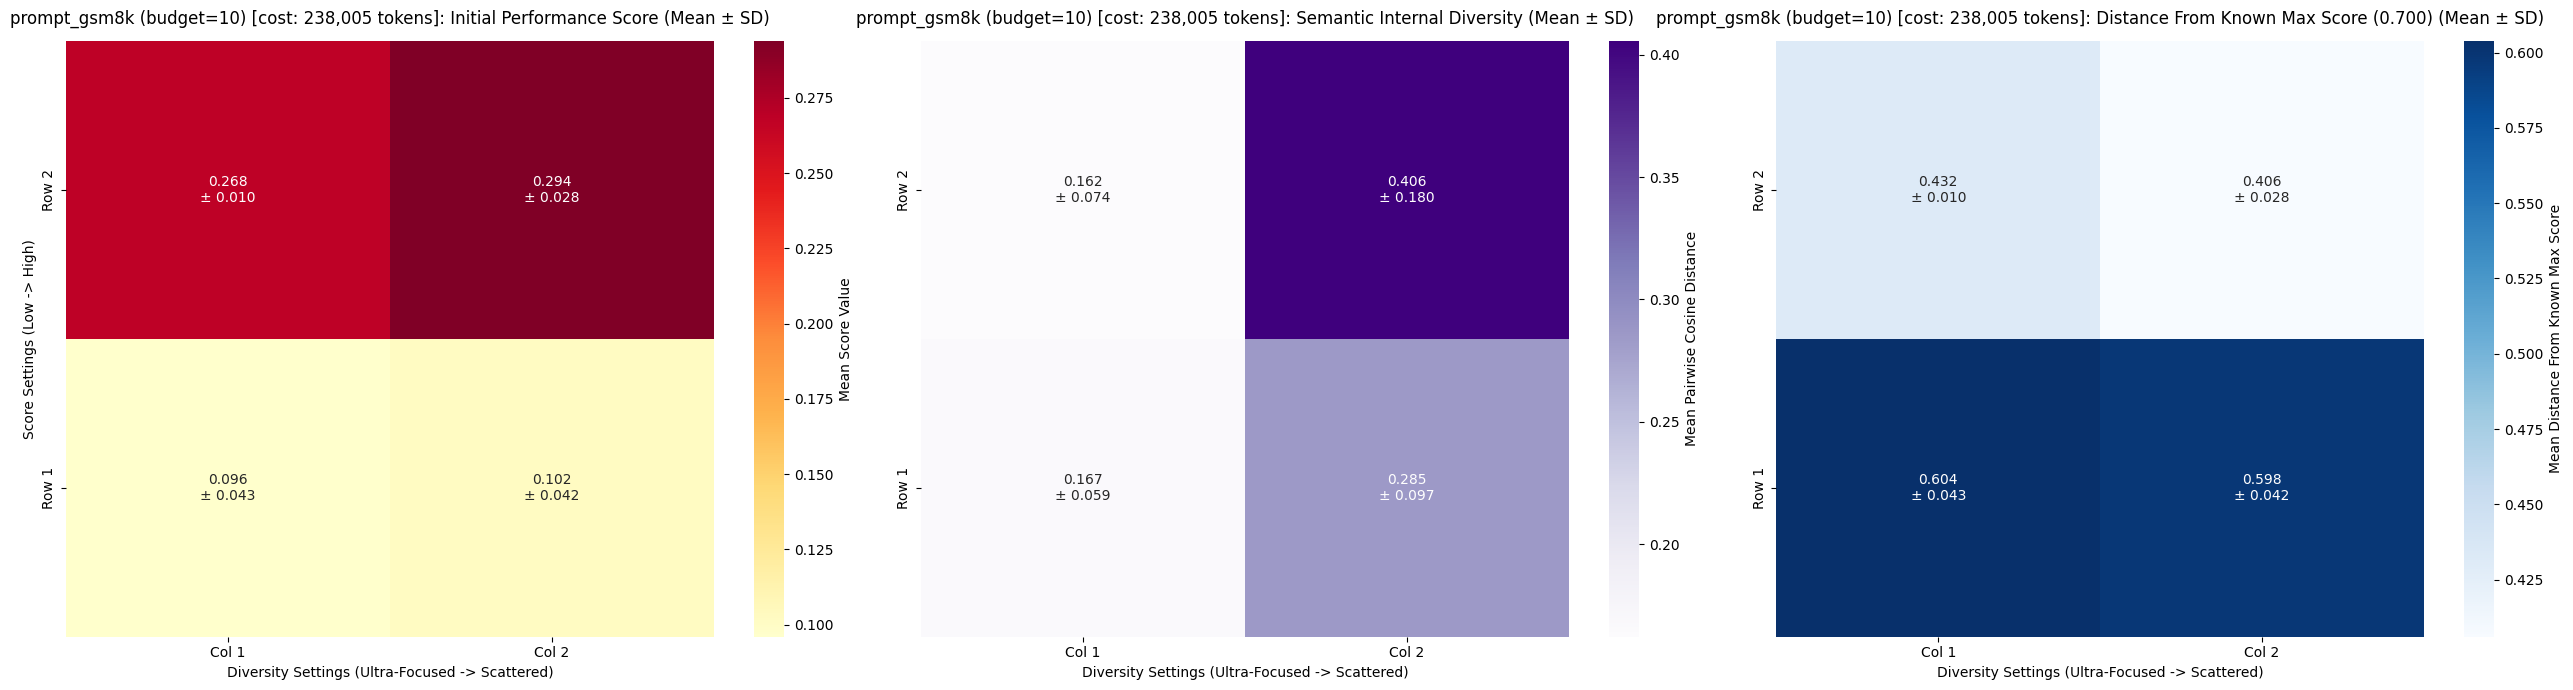


=== prompt_gsm8k/budget_20 ===
prompt/gsm8k (budget=20): pooled 12 opro run dirs -> 240 rows, 196 unique solutions, 535,301 cumulative tokens spent.
choose_grid_size: 196 unique solutions -> 4x3 grid (~16 solutions/cell est.)
Pool size after deduplication: 196 solutions.
embed_with_cache[prompt_gsm8k_opro_iterbudget]: loaded 518 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_gsm8k_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_gsm8k_opro_iterbudget]: all 196 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 12 populations (grid up to 4x3) using seed 42!


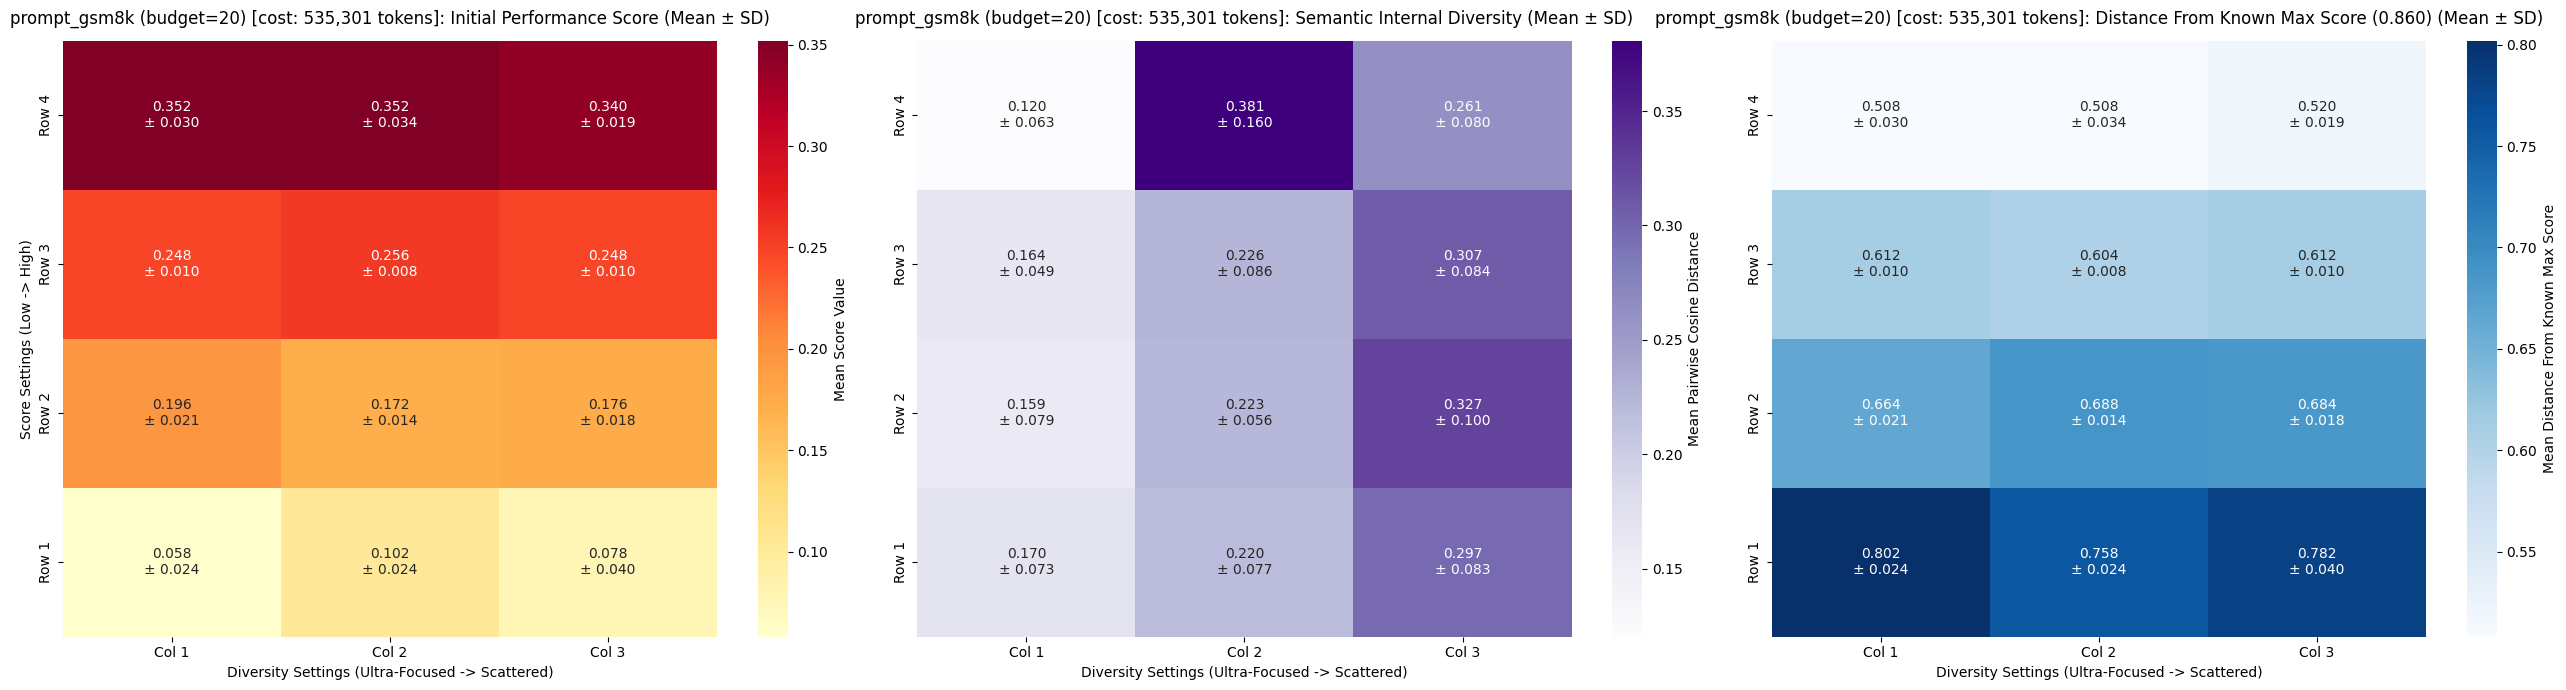


=== prompt_drop/budget_2 ===
prompt/drop (budget=2): pooled 12 opro run dirs -> 24 rows, 13 unique solutions, 20,823 cumulative tokens spent.
choose_grid_size: 13 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 13 solutions.
embed_with_cache[prompt_drop_opro_iterbudget]: loaded 586 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_drop_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_drop_opro_iterbudget]: all 13 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


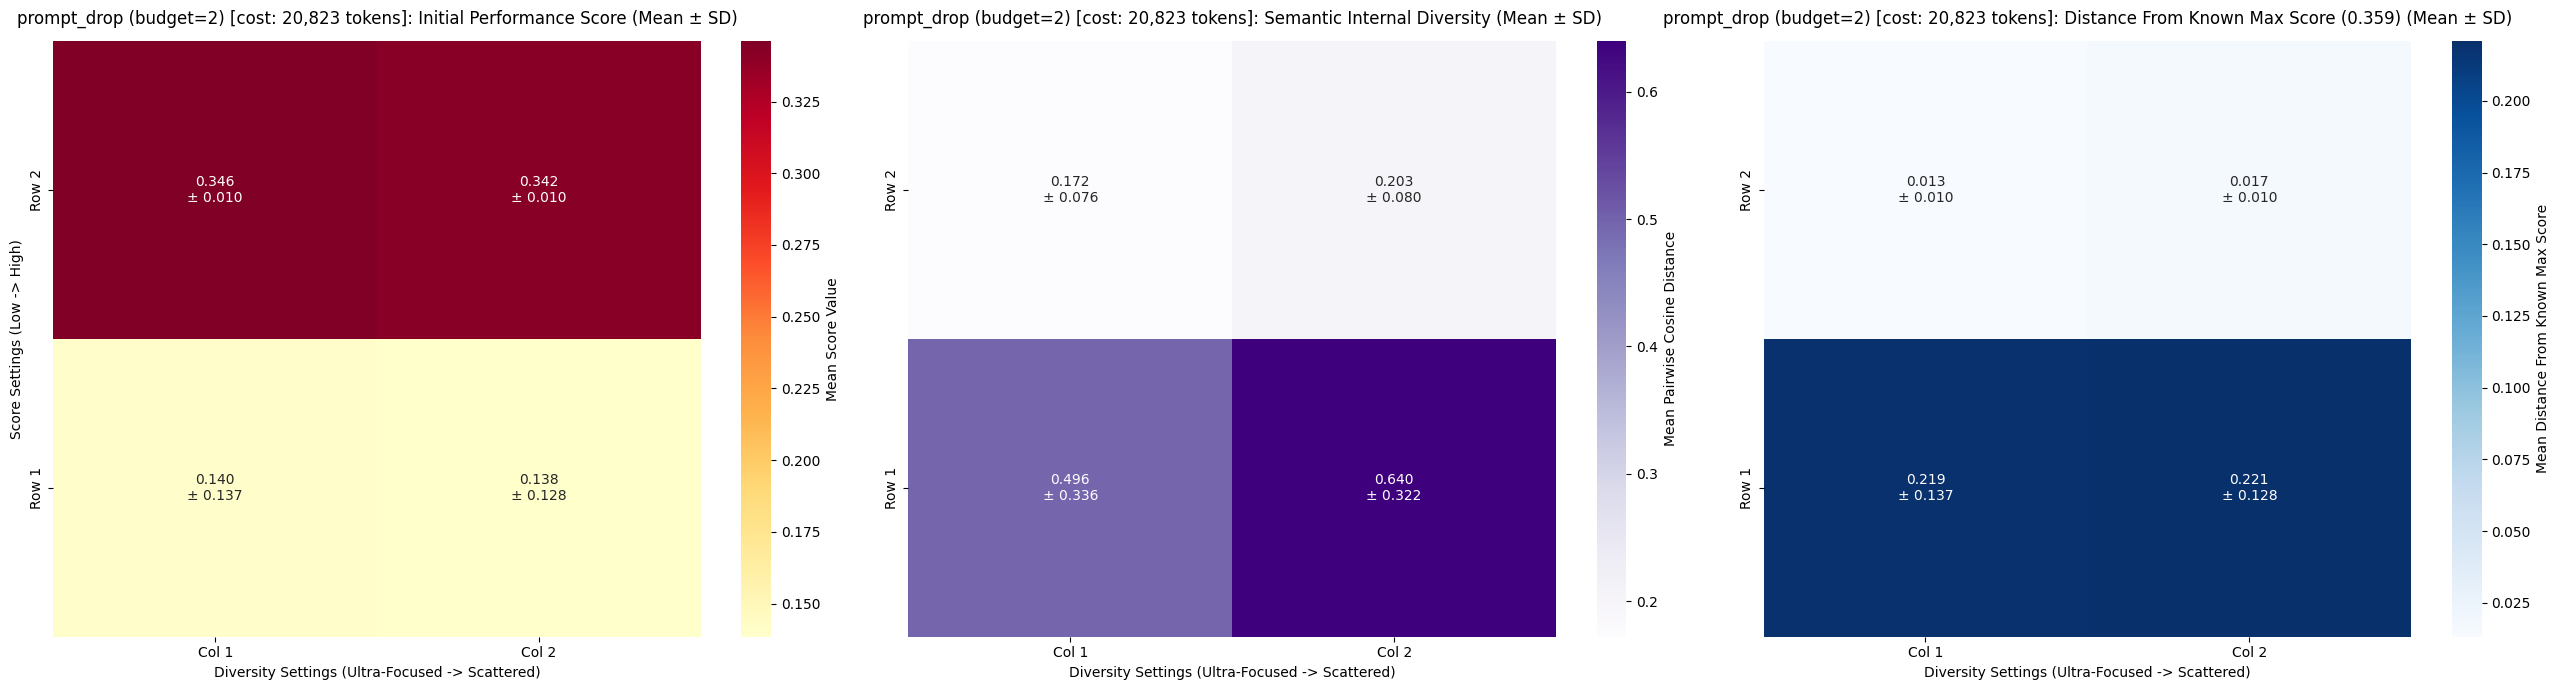


=== prompt_drop/budget_3 ===
prompt/drop (budget=3): pooled 12 opro run dirs -> 36 rows, 25 unique solutions, 49,494 cumulative tokens spent.
choose_grid_size: 25 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 25 solutions.
embed_with_cache[prompt_drop_opro_iterbudget]: loaded 586 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_drop_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_drop_opro_iterbudget]: all 25 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


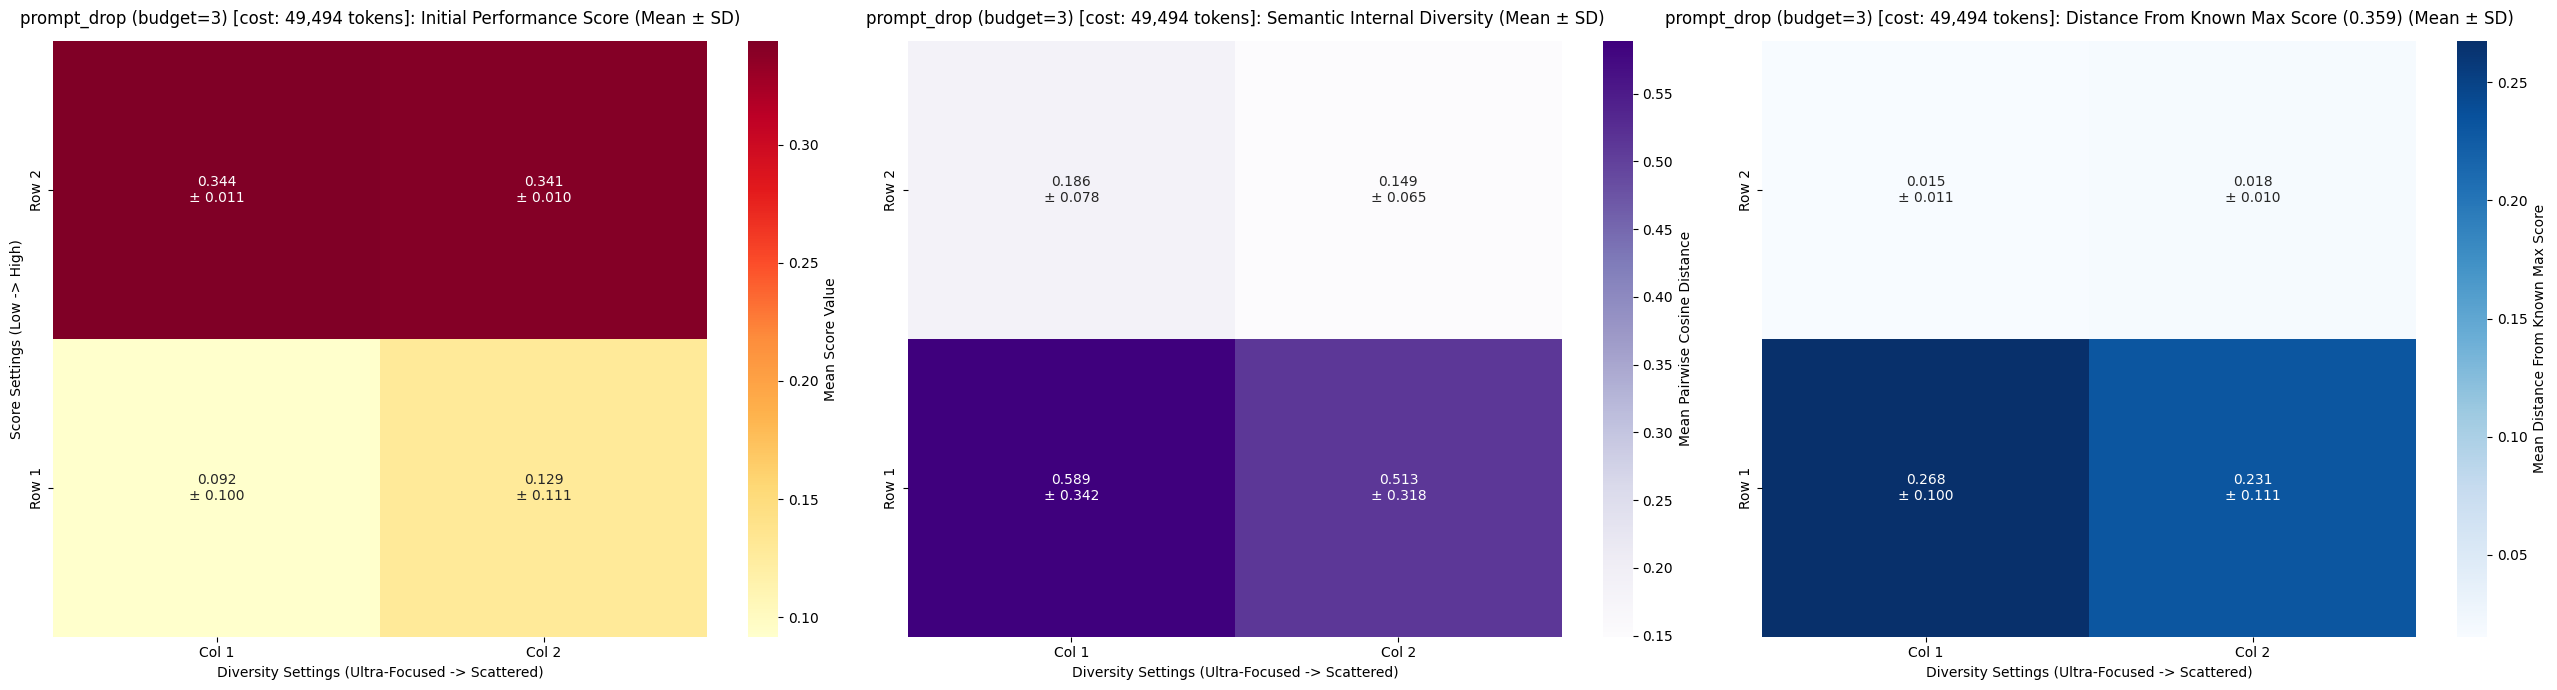


=== prompt_drop/budget_5 ===
prompt/drop (budget=5): pooled 12 opro run dirs -> 60 rows, 49 unique solutions, 112,324 cumulative tokens spent.
choose_grid_size: 49 unique solutions is thin even for the smallest candidate grid 2x2 -- expect the small-cell fallback to kick in for several cells.
Pool size after deduplication: 49 solutions.
embed_with_cache[prompt_drop_opro_iterbudget]: loaded 586 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_drop_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_drop_opro_iterbudget]: all 49 texts already cached -- skipping model load entirely.
 Variance Alert: Row_1_Col_1 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_1
 Variance Alert: Row_1_Col_2 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


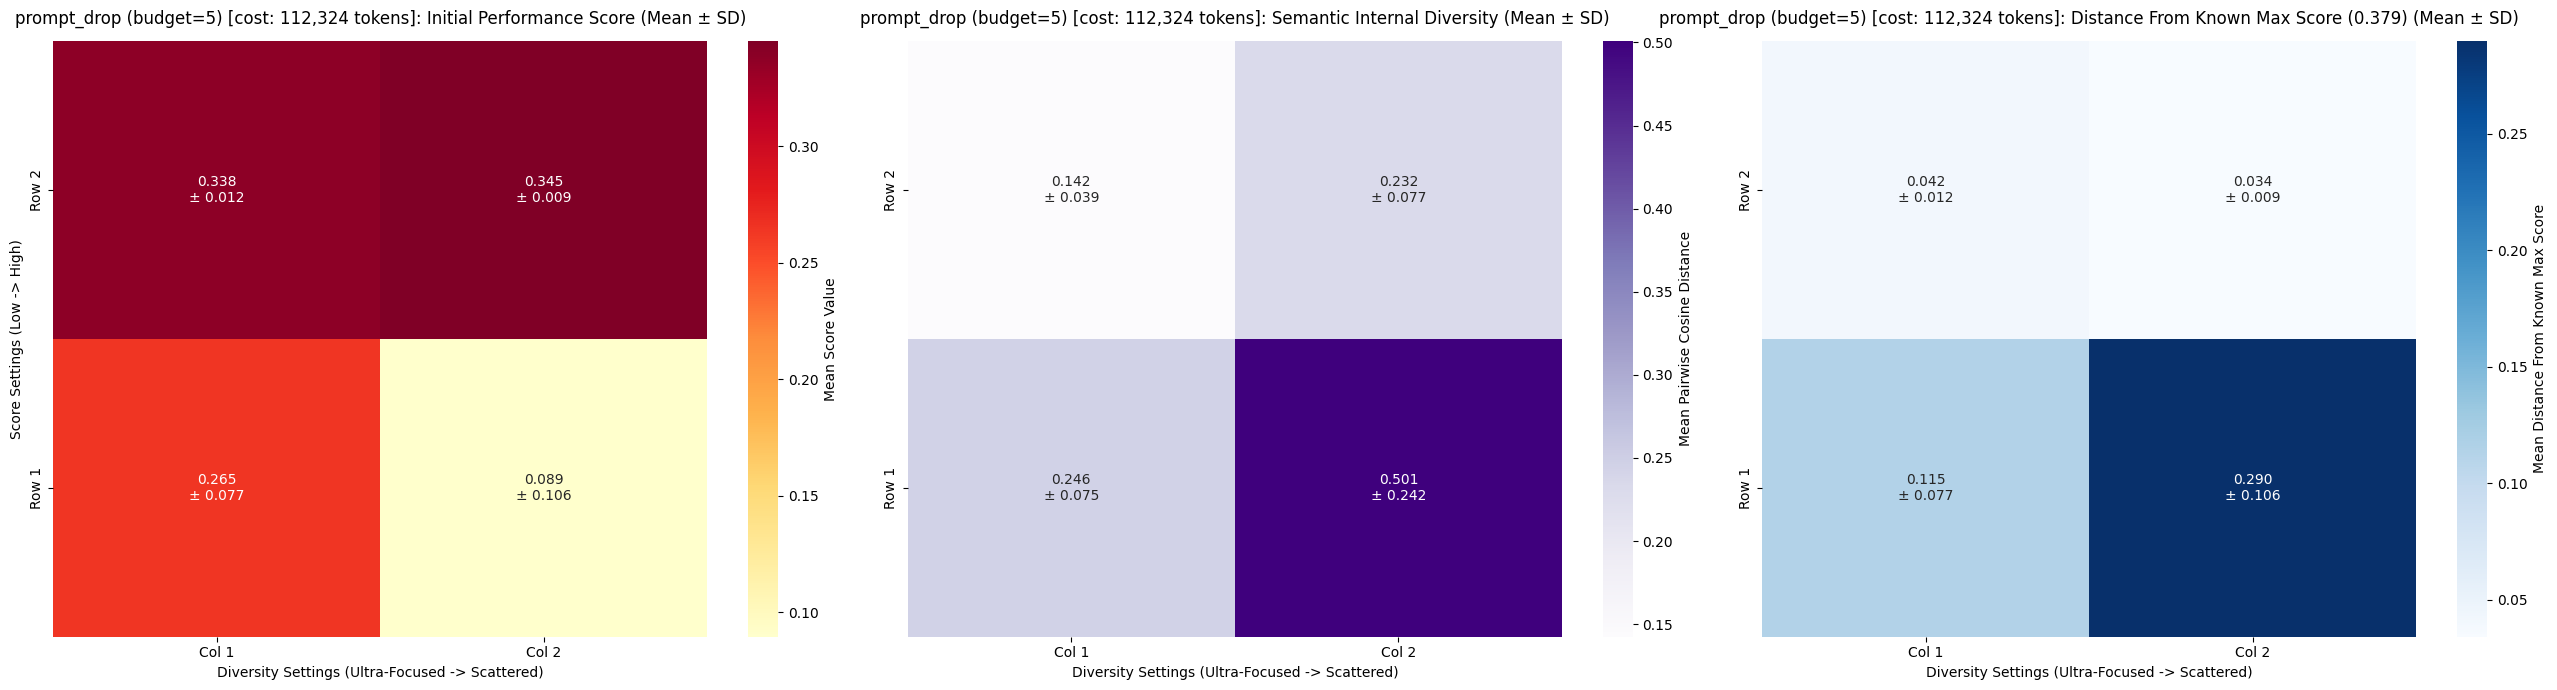


=== prompt_drop/budget_10 ===
prompt/drop (budget=10): pooled 12 opro run dirs -> 120 rows, 109 unique solutions, 298,368 cumulative tokens spent.
choose_grid_size: 109 unique solutions -> 2x2 grid (~27 solutions/cell est.)
Pool size after deduplication: 109 solutions.
embed_with_cache[prompt_drop_opro_iterbudget]: loaded 586 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_drop_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_drop_opro_iterbudget]: all 109 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_2_Col_1
Row_2_Col_2

Successfully built and saved 4 populations (grid up to 2x2) using seed 42!


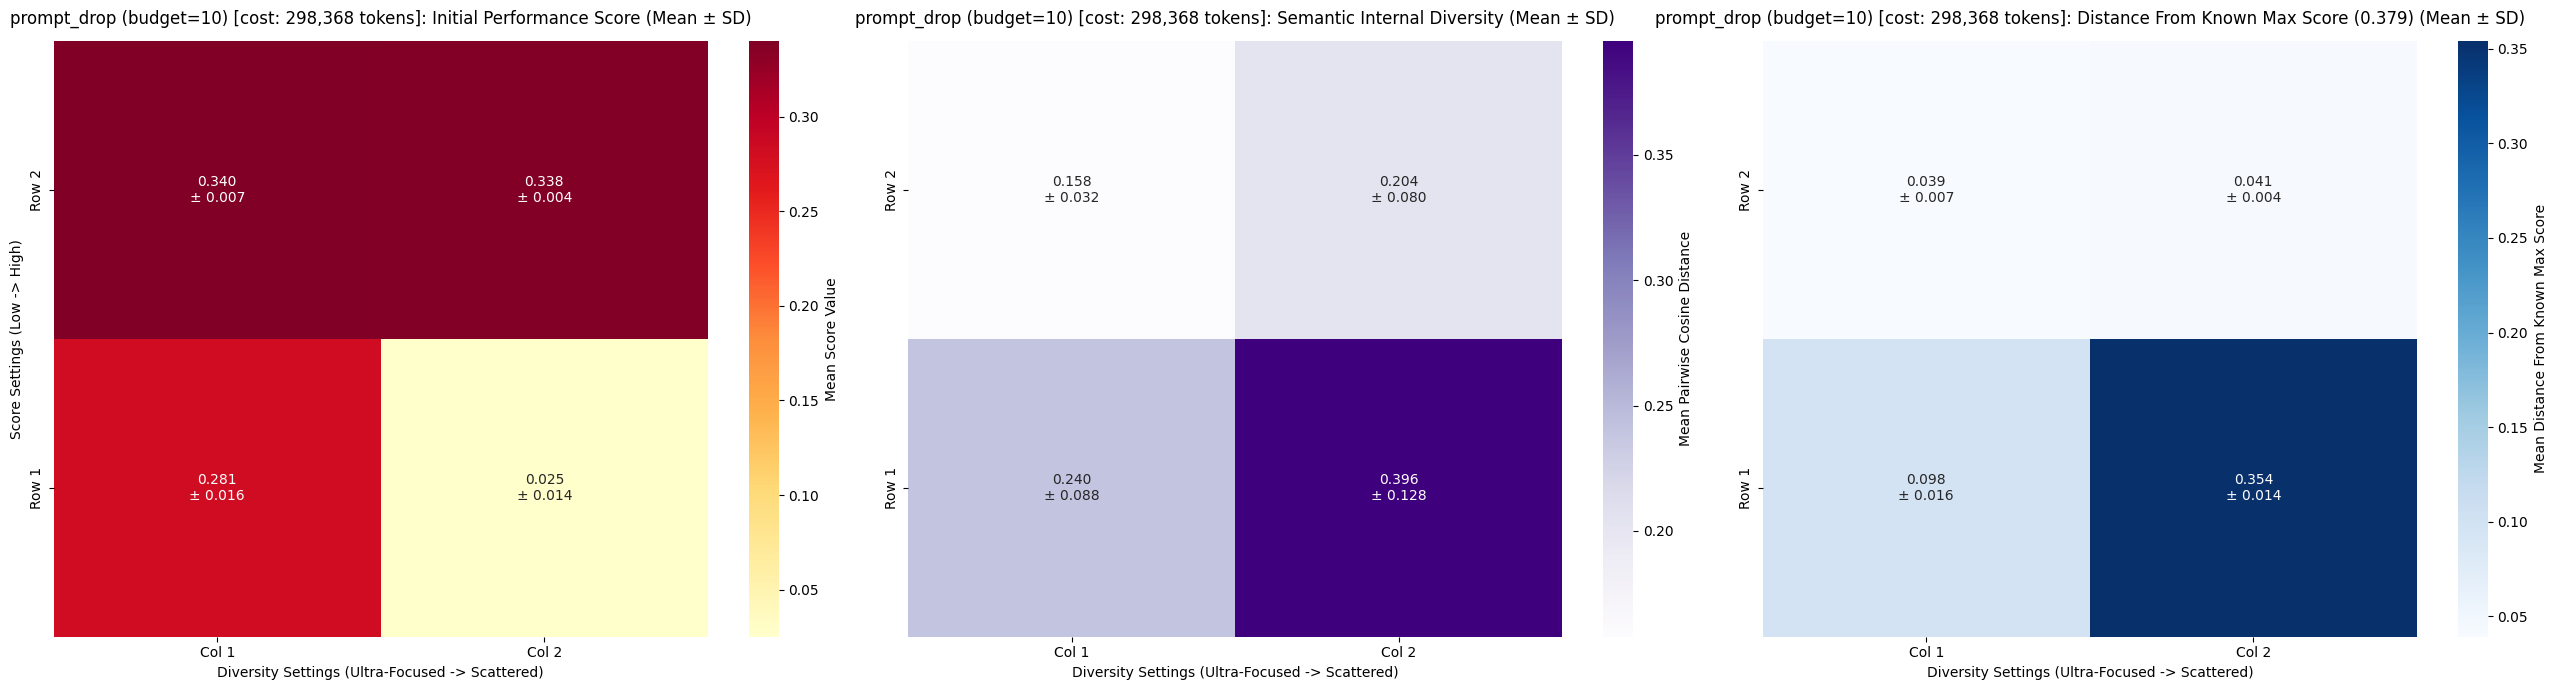


=== prompt_drop/budget_20 ===
prompt/drop (budget=20): pooled 12 opro run dirs -> 240 rows, 229 unique solutions, 674,532 cumulative tokens spent.
choose_grid_size: 229 unique solutions -> 4x3 grid (~19 solutions/cell est.)
Pool size after deduplication: 229 solutions.
embed_with_cache[prompt_drop_opro_iterbudget]: loaded 586 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_drop_opro_iterbudget__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_drop_opro_iterbudget]: all 229 texts already cached -- skipping model load entirely.
 Variance Alert: Row_1_Col_1 couldn't easily find SD < 0.05. Forcing closest scores.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 12 populations (grid up to 4x3) using seed 42!


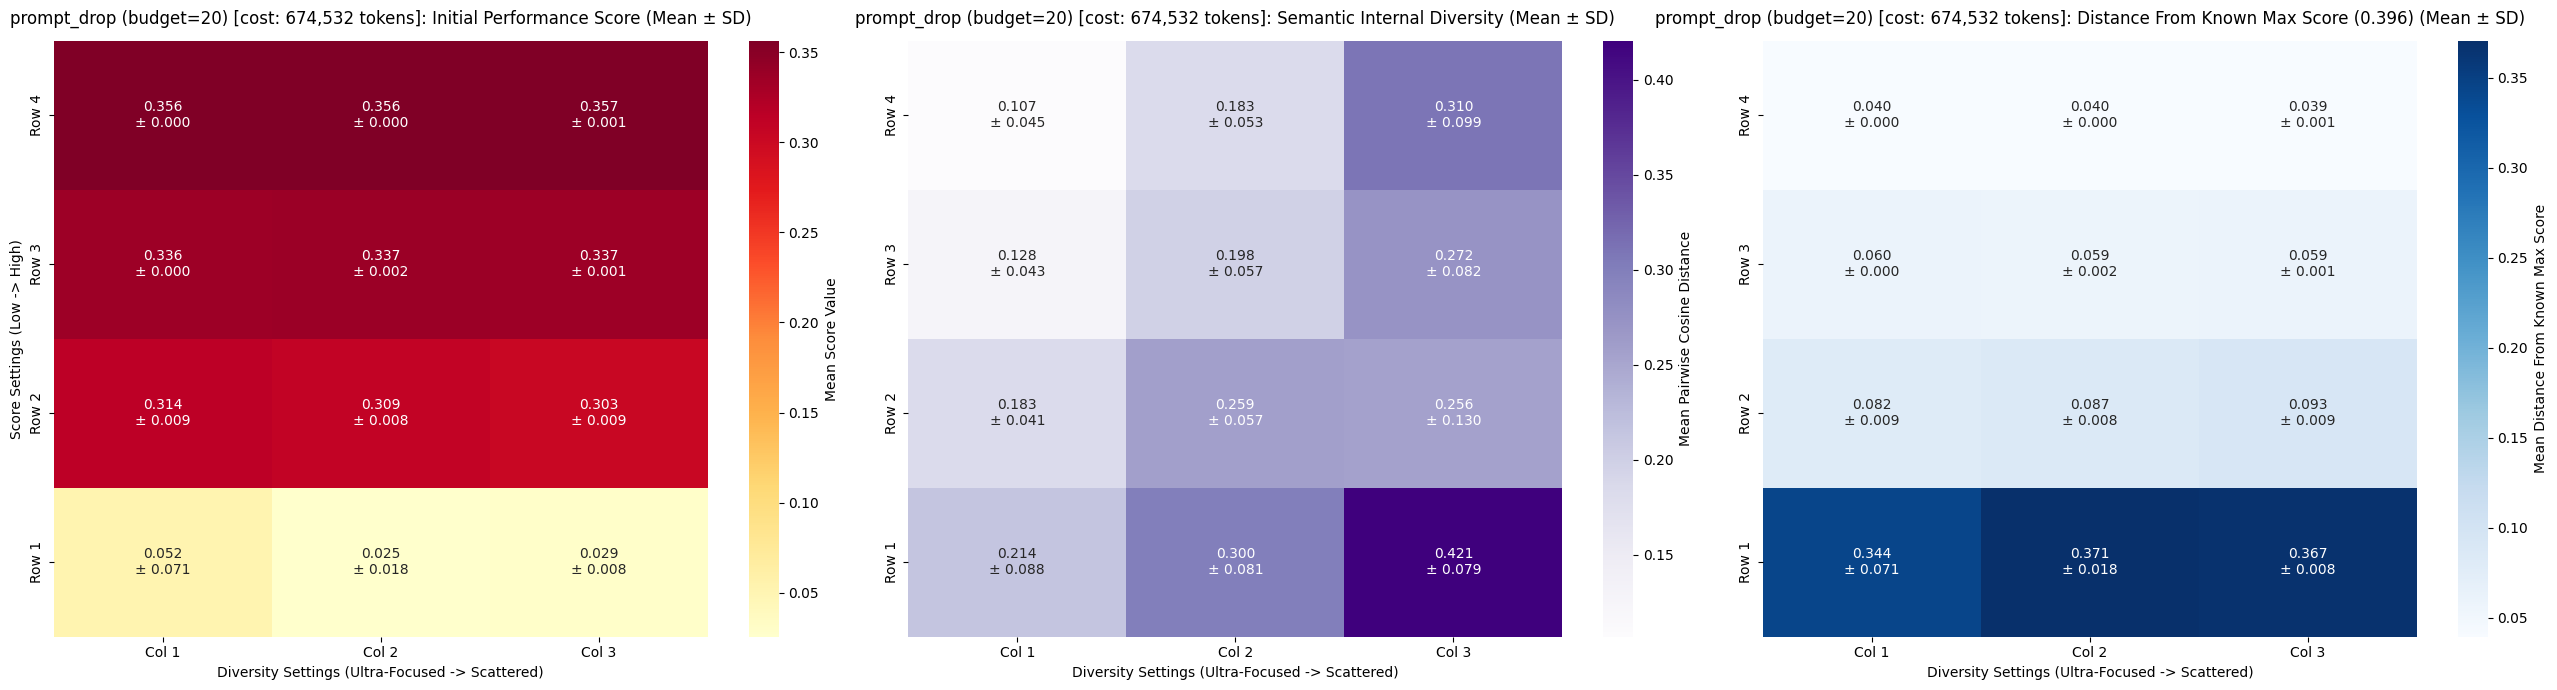

In [10]:
all_budget_pools = {}
all_budget_grids = {}
all_budget_populations = {}
all_budget_summaries = {}
all_budget_costs = {}

for task_name, cfg in TASK_BUDGET_CONFIGS.items():
    for budget in cfg['budgets']:
        run_label = f'{task_name}/budget_{budget}'
        print(f'\n=== {run_label} ===')

        pool_df, cost_tokens = load_pool_from_opro_runs_by_budget(
            GENERAL_ROLLOUT_DIR,
            cfg['task_token'],
            cfg['dataset'],
            budget,
        )
        if pool_df.empty:
            print(f'Skipping {run_label}: no pool data found.')
            continue

        if cfg['score_filter'] is not None:
            n_before = len(pool_df)
            pool_df = pool_df[
                pool_df['score_num'].apply(cfg['score_filter'])
            ].reset_index(drop=True)
            n_dropped = n_before - len(pool_df)
            if n_dropped:
                print(
                    f'{run_label}: dropped {n_dropped} failed-rollout sentinel score(s).'
                )
            if pool_df.empty:
                print(
                    f'Skipping {run_label}: no pool data left after score filtering.'
                )
                continue

        all_budget_pools[run_label] = pool_df
        all_budget_costs[run_label] = cost_tokens

        # Best score seen anywhere in this budget's pooled trajectory (post score-filter,
        # so a failed-rollout sentinel can't masquerade as the "known max") -- the
        # reference point for the third heatmap's per-cell regret ("distance from known
        # max score").
        known_max_score = pool_df['score_num'].max()

        pop_size = cfg['pop_size']
        n_rows, n_cols = choose_grid_size(pool_df, pop_size=pop_size)
        all_budget_grids[run_label] = (n_rows, n_cols)

        # Nested per-task/per-budget output dir (curated_initial_populations_by_iter_budget/
        # <task_name>/budget_<N>/) so every budget's Row_i_Col_j.json files coexist instead
        # of overwriting each other, and so get_args_for_pop_dynamics's non-recursive
        # os.listdir glob still works unmodified when pointed at one of these leaf dirs.
        output_dir = os.path.join(
            POPULATION_DIR, task_name, f'budget_{budget}'
        )

        # Embedding cache is namespaced per task (not per budget): a budget's pool is a
        # strict subset of any larger budget's pool for the same task, so sharing one
        # cache_key means only the newly-seen solutions at each larger budget ever get
        # re-embedded.
        cache_key = f'{task_name}_opro_iterbudget'

        populations = generate_and_save_population_grid(
            pool_df,
            output_dir,
            cfg['embed_model'],
            n_rows=n_rows,
            n_cols=n_cols,
            pop_size=pop_size,
            seed=42,
            trust_remote_code=cfg['trust_remote_code'],
            encode_batch_size=cfg['encode_batch_size'],
            max_seq_length=cfg['max_seq_length'],
            cache_key=cache_key,
        )
        all_budget_populations[run_label] = populations

        summary_df = summarize_and_plot_population_grid(
            populations,
            n_rows,
            n_cols,
            f'{task_name} (budget={budget})',
            known_max_score=known_max_score,
            cost_tokens=cost_tokens,
        )
        all_budget_summaries[run_label] = summary_df